# Notebook 2 of 3 -- Project Walkthrough, Part 1: A Fintech Document-Intelligence Trust Layer

This is the second notebook in a three-part portfolio series built around an Upwork job posting
for a fintech SaaS that processes "high volumes of financial documents daily, including invoices,
bank statements, KYC forms and compliance reports". The client wants: automatic document-type
classification; structured-data extraction from semi-structured/unstructured documents; business-rule
validation before data reaches the core system; low-confidence extractions flagged for human review
instead of failing silently; and REST API integration -- with OCR/layout-awareness and LLM use that
pays attention to reliability and cost control.

**Important framing:** everything below is a *draft scaffold*, not a finished production pipeline and
not a claim of prior experience at this client's scale or with their real documents. Every threshold,
architecture choice, and synthetic-data design decision here is left open for a human collaborator to
reshape. See `## Recap` and `## Limitations and open engineering choices` at the end for exactly what this is
and is not.

**What's synthetic vs. real:**
- The document corpus (invoices, bank statements, KYC forms, compliance reports) is **entirely
  synthetic**, generated with known latent ground truth, precisely so the accuracy/coverage/risk
  statistics below have something checkable to compare against. See `## 2` for why.
- Section `## 4a` makes **real** live HTTP calls to DeepSeek (`deepseek-flash`) on a small stratified
  smoke sample -- not a stub. Calls are disk-cached under `../data/llm_cache/deepseek/`, so re-running
  this notebook after the first pass makes **zero** new live calls (`LLM_STATS["live_calls"]`, printed
  throughout). A hard cap (`MAX_LIVE_CALLS = 150`) protects the budget.
- Everything else in extraction (`## 4b` onward) is a **simulated extractor**: a designed error model
  standing in for a real LLM/OCR extraction pipeline run at scale, clearly labelled "derived here"
  wherever it appears.

Notebook 1 works through the *math* behind three papers on selective/conformal risk control
(cfBH -- Jin & Candes 2023; SCoRE -- Bai & Jin 2026; the per-field Validity Ladder -- Gurram 2026).
Notebook 3 *applies* those papers' guarantees to the pipeline built here. This notebook only builds
the plumbing they need: a corpus with known truth, a classifier, an extractor, business rules, and
five per-field confidence signals -- plus a "current system" folklore baseline audited honestly,
including the caveats about document clustering that make its confidence-threshold policy an
expectation, not a certificate.


## 1. Initial project idea (draft -- open to revision)

The idea sketched out here is a **trust layer for a fintech IDP (intelligent document processing)
pipeline**: classify -> extract -> validate -> per-field confidence -> accept or route to human review.

1. **Classify.** A cheap, fast document-type classifier (TF-IDF + logistic regression) routes each
   incoming document to the right extraction schema. Misclassification cascades into extraction
   failure, so this tier's accuracy and confidence matter even though it looks like the "easy" part.
2. **Extract.** An LLM (or, at production scale, an LLM behind an OCR/layout front end) pulls
   structured fields out of the document text. This notebook smoke-tests a real LLM call on a small
   sample (`## 4a`) and uses a designed simulated extractor for the full corpus (`## 4b`), because
   running thousands of live LLM calls for a portfolio piece is neither necessary nor a responsible
   use of an API budget.
3. **Validate.** Deterministic business rules (arithmetic reconciliation, date ordering, IBAN
   checksums, ID-format checks, enum membership) catch a *subset* of extraction errors and flag which
   fields they touch (`## 5`).
4. **Score confidence.** Per field, combine several signals -- verbalized self-report, k-sample
   self-consistency, grounding/support in the source text, whether a business rule failed, and the
   upstream classifier's confidence -- into a decision: accept automatically, or send to a human
   (`## 6`).
5. **Audit the "current system".** Before reaching for anything from the three papers, replicate the
   folklore policy a team like this is likely already running ("auto-accept if confidence >= 0.9 and
   no rule failure") and audit it honestly on held-out documents, including a caveat about within-
   document error clustering that plain field-level statistics get wrong (`## 7`).

**What this notebook does NOT attempt** (Notebook 3 adds it): none of steps 1-5 above comes with a
statistical *guarantee* yet. Confidence >= 0.9 is a folklore threshold, not a calibrated one; the
Wilson interval in `## 7` treats fields as i.i.d. when they are not. Notebook 3 re-executes this
notebook's code (see the reuse contract note below each core cell) and applies cfBH-style selective
FDR control, SCoRE's bounded-risk e-values, and Gurram's Mondrian LTT / doc-i.i.d. tiers -- each with
its own promise, not one uniform guarantee: cfBH's FDR and SCoRE's SDR/MDR are **expectation**
bounds (E[risk] <= a level), true on average over draws, while only Gurram's Mondrian LTT and
doc-i.i.d. tiers are **PAC** (probability >= 1-delta) certificates with a stated failure probability
(`research/reread.py 7 11`). Neither cfBH nor SCoRE says anything about documents at all -- both are
silent on multi-field/hierarchical structure (`research/reread.py 7 11`: cfBH "is silent on
multi-field hierarchical or document-level clustering"; SCoRE "does not formulate a document-level
clustered extraction protocol"). Running them at the **document** unit in Notebook 3 is therefore the
safe choice this notebook's own `## 7` diagnostic motivates, not something their math requires --
label it **derived here**, same as everything else in this notebook that goes beyond what the three
papers themselves prove.


## 2. Dataset rationale + synthetic corpus with known latent truth (derived here)

**Real stand-ins the human could swap in.** Gurram's Validity Ladder paper (P3) certifies its per-field
selective-risk ladder on three real, public document corpora: **CORD** (scanned Indonesian receipts,
structured key-value fields -- P3's headline Table 4 ladder is CORD x claude-sonnet-5), **FUNSD**
(scanned English forms, free-text-heavy), and **XFUND(-de)** (multilingual scanned forms, German
subset) -- see `research/reread.py 7 9`, Section 7 two-regime results ("FUNSD certifies 0.128
rigorously... XFUND-de is small-n"). CORD's receipt-style key-value structure is the closest real
analogue to this job's invoices; FUNSD's forms are the closest analogue to KYC forms. **Neither P1
(cfBH) nor P2 (SCoRE) uses document-extraction data at all** -- their applications are drug discovery,
hiring, ICU length-of-stay, and (for SCoRE) MIMIC-CXR radiology reports (`research/reread.py 7 11`,
"Neither Jin & Candes... nor Bai & Jin mention document extraction, JSON schemas, or field-level LLM
parsing"). Other real fintech-document sets a human could bring in -- **SROIE**, **DocILE**,
**RVL-CDIP** -- are **not** used by any of the three papers; they're listed here only as options, not
as something this notebook or its citations can vouch for.

None of the three papers' corpora include bank-statement or compliance-report documents specifically,
so this notebook is not trying to reproduce CORD/FUNSD/XFUND pixel-for-pixel -- it builds its own
small, known-truth synthetic corpus across all four of *this client's* document types, for the same
reason the companion NLP-job notebook built a synthetic job-posting corpus: an audit of accuracy,
coverage, and rule-detection power needs a *known* ground truth to check the pipeline's decisions
against, and real unlabelled fintech documents would need exactly the labelling effort this pipeline
is being built to reduce -- a circularity. Swapping in real CORD/FUNSD/XFUND captures (with the
labelling effort that requires) is one of the "engineering choices left open" items in `## 8`.

**The generator (derived here, all of it):**
- 4 document types -- `invoice`, `bank_statement`, `kyc_form`, `compliance_report` -- each with 7-9
  schema-typed fields (amounts, dates, IDs/IBANs, enums, names, free text).
- 2-3 vendor/issuer **templates per type**, each with its own label vocabulary and locale (US / DE /
  FR: different date formats, decimal separators, VAT-style tax rates), plus a **separate set of
  brand-new templates** used only by a "month 7" shifted batch, so that batch carries genuine
  template novelty.
- A simple layout-aware representation: each field is a (label, value) pair placed at a synthetic
  `(x, y)` position; rows are joined in reading order into an "OCR text layer" string, then passed
  through a noise model (character confusions 0/O, 1/l, 5/S; dropped tokens; occasional column
  merges) parameterised by a per-document noise level.
- **Deliberately hard, definition-hard cases**, flagged per document: multiple candidate "total"-like
  numbers on one invoice (subtotal / discount / balance-due decoys), credit notes with negative
  totals, locale-ambiguous amounts (`1.234,56` vs `1,234.56`), locale-ambiguous dates (`03/04/2026`,
  disambiguated only by the template's own locale), genuinely absent fields (truth = `null` --  a
  filled-in prediction there is a *hallucination*, not a hit), `"SURNAME, Given"` name order on some
  KYC/statement templates, heavy-noise scans, and bank-statement transaction lines dropped by OCR so
  that summary totals stop being independently reconcilable from the visible text.
- ~3,000 documents spread over 6 months, plus a separate **month-7 shifted batch** (~500 docs: new
  vendor templates the classifier/extractor never saw, higher baseline OCR noise) held aside for
  Notebook 3's shift/re-certification analysis.
- **Document-level** splits -- `train` / `calib` / `test` at roughly 30/35/35 of months 1-6, `shift`
  as its own held-out split -- because the exchangeability unit the papers care about is the document,
  not the field (`research/reread.py 7 11`: "Gurram... explicitly identifies the document as the true
  unit of exchangeability").
- Canonical, schema-typed correctness: amounts within 0.005 absolute, dates exact after ISO
  normalization, IDs/IBANs exact after whitespace/case normalization, names exact after
  comma-reordering and case normalization, and explicit `null`-vs-value handling (a missing truth
  value is correctly predicted only by predicting `null` too).


In [1]:
%matplotlib inline
import csv
import hashlib
import json
import math
import os
import re
import threading
import time
import urllib.error
import urllib.request
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from datetime import date, timedelta
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

SEED = 20260917
RNG = np.random.default_rng(SEED)

NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data"
CACHE_DIR = DATA_DIR / "llm_cache" / "deepseek"
NB2_DIR = DATA_DIR / "nb2"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
NB2_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_DATE = date(2026, 9, 17)  # "today" for KYC age / ID-expiry checks

PALETTE = {
    "invoice": "#1f77b4", "bank_statement": "#ff7f0e", "kyc_form": "#2ca02c",
    "compliance_report": "#d62728",
    "correct": "#2ca02c", "incorrect": "#d62728",
    "hard": "#d62728", "easy": "#7f7f7f",
    "accept": "#1f77b4", "review": "#ff7f0e",
    "train": "#1f77b4", "calib": "#9467bd", "test": "#2ca02c", "shift": "#d62728",
    "naive_ci": "#1f77b4", "cluster_ci": "#d62728",
    "deepseek": "#1f77b4", "simulated": "#7f7f7f",
    "rule_pass": "#2ca02c", "rule_fail": "#d62728",
    "grid": "#cccccc",
}


def wilson_ci(k, n, alpha=0.05):
    if n == 0:
        return (0.0, 1.0)
    z = NormalDist().inv_cdf(1 - alpha / 2)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = (z * math.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def fmt_ci(ci):
    return f"[{ci[0]:.3f}, {ci[1]:.3f}]"


def check(label, cond, detail=""):
    status = "PASS" if cond else "FAIL"
    print(f"[{status}] {label}" + (f" -- {detail}" if detail else ""))
    return cond


def to_native(obj):
    # Recursively coerce numpy scalars to native python types so json/csv export never chokes.
    if isinstance(obj, dict):
        return {k: to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [to_native(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    if isinstance(obj, np.str_):
        return str(obj)
    return obj


print("Setup cell loaded. SEED =", SEED)


Setup cell loaded. SEED = 20260917


In [2]:
FIELD_SCHEMAS = {
    "invoice": ["vendor_name", "invoice_number", "invoice_date", "due_date", "currency",
                "subtotal", "tax_amount", "total_amount", "iban"],
    "bank_statement": ["account_holder", "iban", "period_start", "period_end",
                        "opening_balance", "total_credits", "total_debits", "closing_balance"],
    "kyc_form": ["full_name", "date_of_birth", "nationality", "id_type", "id_number",
                 "id_expiry", "address", "pep_flag"],
    "compliance_report": ["entity_name", "report_date", "period", "risk_rating",
                           "sar_filed", "total_flagged_amount", "reviewer_name"],
}

FIELD_TYPES = {
    "vendor_name": "name", "invoice_number": "id", "invoice_date": "date", "due_date": "date",
    "currency": "enum", "subtotal": "amount", "tax_amount": "amount", "total_amount": "amount",
    "iban": "iban",
    "account_holder": "name", "period_start": "date", "period_end": "date",
    "opening_balance": "amount", "total_credits": "amount", "total_debits": "amount",
    "closing_balance": "amount",
    "full_name": "name", "date_of_birth": "date", "nationality": "enum", "id_type": "enum",
    "id_number": "id", "id_expiry": "date", "address": "text", "pep_flag": "bool_enum",
    "entity_name": "name", "report_date": "date", "period": "text", "risk_rating": "enum",
    "sar_filed": "bool_enum", "total_flagged_amount": "amount", "reviewer_name": "name",
}

MONEY_FIELDS = {"subtotal", "tax_amount", "total_amount", "opening_balance", "total_credits",
                 "total_debits", "closing_balance", "total_flagged_amount"}

DOC_TYPES = list(FIELD_SCHEMAS.keys())

LOCALES = {
    "US": dict(date_fmt="%m/%d/%Y", decimal=".", thousands=",", currency="USD"),
    "DE": dict(date_fmt="%d.%m.%Y", decimal=",", thousands=".", currency="EUR"),
    "FR": dict(date_fmt="%d/%m/%Y", decimal=",", thousands=" ", currency="EUR"),
}

_template_specs = {
    "invoice": [
        ("inv_us_acme", "US", {"vendor_name": "Vendor", "invoice_number": "Invoice #",
         "invoice_date": "Invoice Date", "due_date": "Due Date", "currency": "Currency",
         "subtotal": "Subtotal", "tax_amount": "Tax", "total_amount": "Total Due", "iban": "IBAN"}),
        ("inv_de_globex", "DE", {"vendor_name": "Lieferant", "invoice_number": "Rechnungsnr.",
         "invoice_date": "Rechnungsdatum", "due_date": "Faelligkeitsdatum", "currency": "Waehrung",
         "subtotal": "Zwischensumme", "tax_amount": "MwSt.", "total_amount": "Gesamtbetrag",
         "iban": "IBAN"}),
        ("inv_fr_soleil", "FR", {"vendor_name": "Fournisseur", "invoice_number": "Facture n",
         "invoice_date": "Date de facture", "due_date": "Date d'echeance", "currency": "Devise",
         "subtotal": "Sous-total", "tax_amount": "TVA", "total_amount": "Total a payer",
         "iban": "IBAN"}),
        # Revision item 1/2: a generic-vocabulary template, deliberately overlapping with the other
        # 3 types' generic templates below (Name/Date/Reference/Amount/Number), so TF-IDF cannot
        # lean on label words alone for every document.
        ("inv_generic", "US", {"vendor_name": "Name", "invoice_number": "Reference",
         "invoice_date": "Date", "due_date": "Due", "currency": "Ccy", "subtotal": "Amount",
         "tax_amount": "Charge", "total_amount": "Total", "iban": "Account"}),
    ],
    "bank_statement": [
        ("stmt_us_firstnat", "US", {"account_holder": "Account Holder", "iban": "IBAN",
         "period_start": "Statement Period From", "period_end": "To",
         "opening_balance": "Opening Balance", "total_credits": "Total Credits",
         "total_debits": "Total Debits", "closing_balance": "Closing Balance"}),
        ("stmt_de_sparkasse", "DE", {"account_holder": "Kontoinhaber", "iban": "IBAN",
         "period_start": "Zeitraum von", "period_end": "bis", "opening_balance": "Anfangssaldo",
         "total_credits": "Summe Gutschriften", "total_debits": "Summe Belastungen",
         "closing_balance": "Endsaldo"}),
        ("stmt_generic", "US", {"account_holder": "Name", "iban": "Account",
         "period_start": "Date From", "period_end": "Date To", "opening_balance": "Start Amount",
         "total_credits": "In", "total_debits": "Out", "closing_balance": "End Amount"}),
    ],
    "kyc_form": [
        ("kyc_us_std", "US", {"full_name": "Full Name", "date_of_birth": "Date of Birth",
         "nationality": "Nationality", "id_type": "ID Type", "id_number": "ID Number",
         "id_expiry": "ID Expiry", "address": "Address", "pep_flag": "PEP"}),
        ("kyc_fr_std", "FR", {"full_name": "Nom complet", "date_of_birth": "Date de naissance",
         "nationality": "Nationalite", "id_type": "Type de piece", "id_number": "Numero de piece",
         "id_expiry": "Date d'expiration", "address": "Adresse", "pep_flag": "PPE"}),
        ("kyc_generic", "US", {"full_name": "Name", "date_of_birth": "Date", "nationality": "Country",
         "id_type": "Type", "id_number": "Reference", "id_expiry": "Valid Until",
         "address": "Address", "pep_flag": "Flag"}),
    ],
    "compliance_report": [
        ("comp_us_std", "US", {"entity_name": "Entity", "report_date": "Report Date",
         "period": "Reporting Period", "risk_rating": "Risk Rating", "sar_filed": "SAR Filed",
         "total_flagged_amount": "Total Flagged Amount", "reviewer_name": "Reviewer"}),
        ("comp_de_std", "DE", {"entity_name": "Unternehmen", "report_date": "Berichtsdatum",
         "period": "Berichtszeitraum", "risk_rating": "Risikoeinstufung",
         "sar_filed": "Verdachtsmeldung", "total_flagged_amount": "Gemeldeter Betrag",
         "reviewer_name": "Pruefer"}),
        ("comp_generic", "US", {"entity_name": "Name", "report_date": "Date", "period": "Period",
         "risk_rating": "Rating", "sar_filed": "Flag", "total_flagged_amount": "Amount",
         "reviewer_name": "Reviewer"}),
    ],
}
VENDOR_TEMPLATES = []
for _dtype, _specs in _template_specs.items():
    for _tid, _locale, _labels in _specs:
        VENDOR_TEMPLATES.append({"id": _tid, "doc_type": _dtype, "locale": _locale, "labels": _labels})
TEMPLATES_BY_TYPE = defaultdict(list)
for _t in VENDOR_TEMPLATES:
    TEMPLATES_BY_TYPE[_t["doc_type"]].append(_t)

# Month-7 shift batch: brand-new vendor templates never seen in months 1-6 (template novelty).
_shift_specs = {
    "invoice": ("inv_gb_newco", "US", {"vendor_name": "Supplier", "invoice_number": "Inv No",
         "invoice_date": "Date Issued", "due_date": "Payment Due", "currency": "Ccy",
         "subtotal": "Net Amount", "tax_amount": "VAT", "total_amount": "Amount Payable",
         "iban": "IBAN"}),
    "bank_statement": ("stmt_fr_credit", "FR", {"account_holder": "Titulaire du compte",
         "iban": "IBAN", "period_start": "Periode du", "period_end": "au",
         "opening_balance": "Solde initial", "total_credits": "Total credits",
         "total_debits": "Total debits", "closing_balance": "Solde final"}),
    "kyc_form": ("kyc_de_std", "DE", {"full_name": "Vollstaendiger Name",
         "date_of_birth": "Geburtsdatum", "nationality": "Staatsangehoerigkeit",
         "id_type": "Ausweisart", "id_number": "Ausweisnummer", "id_expiry": "Gueltig bis",
         "address": "Anschrift", "pep_flag": "PEP-Status"}),
    "compliance_report": ("comp_fr_std", "FR", {"entity_name": "Entite",
         "report_date": "Date du rapport", "period": "Periode",
         "risk_rating": "Niveau de risque", "sar_filed": "Declaration deposee",
         "total_flagged_amount": "Montant signale", "reviewer_name": "Examinateur"}),
}
SHIFT_TEMPLATES = [{"id": tid, "doc_type": dt, "locale": loc, "labels": labels}
                    for dt, (tid, loc, labels) in _shift_specs.items()]


def iban_check_digits_valid(iban):
    s = re.sub(r"\s", "", str(iban)).upper()
    if len(s) < 5 or not s[:2].isalpha() or not s[2:4].isdigit():
        return False
    rearranged = s[4:] + s[:4]
    digits = ""
    for ch in rearranged:
        if ch.isdigit():
            digits += ch
        elif ch.isalpha():
            digits += str(ord(ch) - ord("A") + 10)
        else:
            return False
    try:
        return int(digits) % 97 == 1
    except ValueError:
        return False


def make_valid_iban(country, rng):
    bank = "".join(str(int(rng.integers(0, 10))) for _ in range(8))
    acct = "".join(str(int(rng.integers(0, 10))) for _ in range(10))
    bban = bank + acct
    check_body = bban + country + "00"
    digits = "".join(str(ord(ch) - ord("A") + 10) if ch.isalpha() else ch for ch in check_body)
    remainder = int(digits) % 97
    check = 98 - remainder
    return f"{country}{check:02d}{bban}"


def normalize_name(s):
    if s is None:
        return None
    s = str(s).strip()
    if "," in s:
        last, _, first = s.partition(",")
        s = f"{first.strip()} {last.strip()}"
    return " ".join(s.lower().split())


def normalize_text(s):
    if s is None:
        return None
    return " ".join(str(s).strip().lower().split())


def normalize_id(s):
    if s is None:
        return None
    return re.sub(r"[\s-]", "", str(s)).upper()


ENUM_SYNONYMS = {
    "yes": {"yes", "y", "true", "oui", "ja"},
    "no": {"no", "n", "false", "non", "nein"},
}


def normalize_enum(s):
    if s is None:
        return None
    v = str(s).strip().lower()
    for canon, syns in ENUM_SYNONYMS.items():
        if v in syns:
            return canon
    return v


def score_field(field, truth, pred):
    """Schema-typed correctness. Returns (correct: 0/1, err_type)."""
    ftype = FIELD_TYPES[field]
    if truth is None:
        return (1, "ok") if pred is None else (0, "hallucination")
    if pred is None:
        return 0, "omission"
    if ftype == "amount":
        try:
            ok = abs(float(pred) - float(truth)) <= 0.005
        except (TypeError, ValueError):
            ok = False
        return (1, "ok") if ok else (0, "wrong_value")
    if ftype == "date":
        return (1, "ok") if str(pred) == str(truth) else (0, "wrong_value")
    if ftype in ("id", "iban"):
        return (1, "ok") if normalize_id(pred) == normalize_id(truth) else (0, "wrong_value")
    if ftype == "name":
        return (1, "ok") if normalize_name(pred) == normalize_name(truth) else (0, "wrong_value")
    if ftype in ("enum", "bool_enum"):
        return (1, "ok") if normalize_enum(pred) == normalize_enum(truth) else (0, "wrong_value")
    return (1, "ok") if normalize_text(pred) == normalize_text(truth) else (0, "wrong_value")


print(f"{len(VENDOR_TEMPLATES)} vendor templates, {len(SHIFT_TEMPLATES)} shift templates defined.")


13 vendor templates, 4 shift templates defined.


In [3]:
# Self-checks: IBAN mod-97 checksum, and score_field edge cases.
_real_iban = "GB82 WEST 1234 5698 7654 32"  # a well-known worked example of a valid IBAN
check("IBAN checksum accepts a known-valid IBAN", iban_check_digits_valid(_real_iban))
_bad_iban = "GB83 WEST 1234 5698 7654 32"  # one check digit off
check("IBAN checksum rejects a corrupted IBAN", not iban_check_digits_valid(_bad_iban))
for _ in range(20):
    _country = RNG.choice(["DE", "FR", "GB"])
    _gen = make_valid_iban(str(_country), RNG)
    assert iban_check_digits_valid(_gen), _gen
check("make_valid_iban always produces a checksum-valid IBAN", True, "20/20 sampled")

check("score_field: null truth + null pred is correct", score_field("due_date", None, None) == (1, "ok"))
check("score_field: null truth + filled pred is hallucination",
      score_field("due_date", None, "2026-01-01")[1] == "hallucination")
check("score_field: filled truth + null pred is omission",
      score_field("due_date", "2026-01-01", None)[1] == "omission")
check("score_field: amount tolerance 0.005 boundary", score_field("subtotal", 100.00, 100.005) == (1, "ok"))
check("score_field: amount just outside tolerance is wrong",
      score_field("subtotal", 100.00, 100.01)[0] == 0)
check("score_field: name order + case are normalized",
      score_field("full_name", "John Smith", "SMITH, john") == (1, "ok"))
check("score_field: enum synonyms normalize", score_field("pep_flag", "yes", "Y") == (1, "ok"))


[PASS] IBAN checksum accepts a known-valid IBAN
[PASS] IBAN checksum rejects a corrupted IBAN
[PASS] make_valid_iban always produces a checksum-valid IBAN -- 20/20 sampled
[PASS] score_field: null truth + null pred is correct
[PASS] score_field: null truth + filled pred is hallucination
[PASS] score_field: filled truth + null pred is omission
[PASS] score_field: amount tolerance 0.005 boundary
[PASS] score_field: amount just outside tolerance is wrong
[PASS] score_field: name order + case are normalized
[PASS] score_field: enum synonyms normalize


True

In [4]:
FIRST_NAMES = ["John", "Maria", "Wei", "Fatima", "Carlos", "Anna", "Yuki", "Ahmed", "Sofia", "Lucas",
               "Emma", "Noah", "Olga", "Hassan", "Chidi", "Ingrid", "Diego", "Priya", "Marco", "Elena"]
LAST_NAMES = ["Smith", "Garcia", "Mueller", "Dubois", "Nguyen", "Kowalski", "Rossi", "Silva", "Khan",
              "Ivanov", "Johnson", "Fischer", "Lefevre", "Costa", "Petrov", "Andersson", "Yamamoto",
              "Haddad", "Okafor", "Novak"]
COMPANY_NAMES = ["Acme Logistics GmbH", "Globex Trading SARL", "Northwind Partners Ltd",
                  "Soleil Import-Export", "BlueRiver Manufacturing", "Delta Consulting AG",
                  "Orion Freight Co", "Meridian Textiles", "Cascade Energy Ltd",
                  "Vantage Analytics Inc", "Ferrum Steelworks", "Lumen Media Group"]
COUNTRIES = ["US", "DE", "FR", "GB", "NL", "IT", "ES", "PL", "IE", "BE"]


def rand_name(rng):
    return f"{FIRST_NAMES[int(rng.integers(0, len(FIRST_NAMES)))]} {LAST_NAMES[int(rng.integers(0, len(LAST_NAMES)))]}"


def rand_company(rng):
    return COMPANY_NAMES[int(rng.integers(0, len(COMPANY_NAMES)))]


def rand_amount(rng, lo, hi):
    return round(float(rng.uniform(lo, hi)), 2)


def rand_date(rng, start, end):
    days = max(1, (end - start).days)
    return start + timedelta(days=int(rng.integers(0, days)))


HARD_FLAGS_BY_TYPE = {
    "invoice": ["multi_total_decoy", "credit_note", "invalid_source_iban", "ambiguous_type_remit"],
    "bank_statement": ["lost_lines", "name_order", "invalid_source_iban", "ambiguous_type_universal"],
    "kyc_form": ["name_order", "ambiguous_type_proof_of_address"],
    "compliance_report": ["ambiguous_type_embedded_invoice"],
}
HARD_FLAG_PROB = {"multi_total_decoy": 0.14, "credit_note": 0.07, "invalid_source_iban": 0.05,
                   "lost_lines": 0.14, "name_order": 0.18,
                   # classification-ambiguity flags (revision item 1): the document's TRUE
                   # doc_type/schema/fields are unchanged -- only the surface OCR text is made to
                   # read like another document type, so the classifier (not the extractor's ground
                   # truth) is what gets confused.
                   "ambiguous_type_remit": 0.10, "ambiguous_type_proof_of_address": 0.10,
                   "ambiguous_type_embedded_invoice": 0.10, "ambiguous_type_universal": 0.10}

# Fields sharing a FIELD_TYPE get the SAME generic label regardless of doc_type when an
# ambiguous_type_* flag fires -- this is the real lever for classification ambiguity: a
# vocabulary-based classifier cannot use label words at all on these documents, only field VALUES
# (which carry far weaker per-type signal), because every type renders "Name: ...", "Date: ...",
# "Amount: ..." identically.
UNIVERSAL_LABEL = {"name": "Name", "date": "Date", "id": "Number", "amount": "Amount",
                    "enum": "Type", "bool_enum": "Status", "iban": "Number", "text": "Details"}
AMBIGUOUS_TYPE_FLAG_NAMES = {"ambiguous_type_remit", "ambiguous_type_proof_of_address",
                              "ambiguous_type_embedded_invoice", "ambiguous_type_universal"}


def assign_hard_flags(rng, doc_type, locale, is_shift):
    flags = set()
    for f in HARD_FLAGS_BY_TYPE[doc_type]:
        p = HARD_FLAG_PROB[f]
        if rng.random() < p:
            flags.add(f)
    if rng.random() < (0.35 if is_shift else 0.12):
        flags.add("heavy_noise")
    if locale in ("US", "FR") and rng.random() < 0.55:
        flags.add("ambiguous_date")
    if locale in ("DE", "FR"):
        flags.add("locale_amount")
    if is_shift:
        flags.add("template_novelty")
    # very_short: applies across all 4 types -- a document with almost no visible content at all,
    # which starves the classifier (and the extractor) of signal regardless of vocabulary.
    if rng.random() < 0.08:
        flags.add("very_short")
    return flags


def pick_noise_level(rng, hard_flags, is_shift):
    if "heavy_noise" in hard_flags:
        return "high"
    if is_shift:
        return "medium" if rng.random() < 0.6 else "high"
    r = rng.random()
    return "low" if r < 0.6 else ("medium" if r < 0.9 else "high")


def gen_invoice_truth(rng, template, month, hard_flags):
    locale = template["locale"]
    loc = LOCALES[locale]
    t = {"vendor_name": rand_company(rng), "invoice_number": f"INV-{int(rng.integers(100000, 999999))}"}
    start = date(2026, month, 1)
    inv_date = rand_date(rng, start, start + timedelta(days=27))
    t["invoice_date"] = inv_date.isoformat()
    t["due_date"] = None if rng.random() < 0.12 else (
        inv_date + timedelta(days=int([15, 30, 45][int(rng.integers(0, 3))]))).isoformat()
    t["currency"] = loc["currency"]
    subtotal = rand_amount(rng, 100, 20000)
    tax_rate = {"US": 0.0, "DE": 0.19, "FR": 0.20}[locale]
    tax = round(subtotal * tax_rate, 2)
    total = round(subtotal + tax, 2)
    if "credit_note" in hard_flags:
        subtotal, tax, total = -subtotal, -tax, -total
    t["subtotal"], t["tax_amount"], t["total_amount"] = subtotal, tax, total
    if rng.random() < 0.08:
        t["iban"] = None
    else:
        iban = make_valid_iban(locale if locale in ("DE", "FR") else "GB", rng)
        if "invalid_source_iban" in hard_flags:
            last = iban[-1]
            iban = iban[:-1] + (str((int(last) + 1) % 10) if last.isdigit() else "9")
        t["iban"] = iban
    return t


def gen_statement_truth(rng, template, month, hard_flags):
    locale = template["locale"]
    t = {"account_holder": rand_name(rng)}
    start = date(2026, month, 1)
    end = start + timedelta(days=27)
    t["period_start"], t["period_end"] = start.isoformat(), end.isoformat()
    opening = rand_amount(rng, 500, 30000)
    credits = rand_amount(rng, 200, 15000)
    debits = rand_amount(rng, 200, 15000)
    t["opening_balance"] = opening
    t["total_credits"] = credits
    t["total_debits"] = debits
    t["closing_balance"] = round(opening + credits - debits, 2)
    if rng.random() < 0.05:
        t["iban"] = None
    else:
        iban = make_valid_iban(locale if locale in ("DE", "FR") else "GB", rng)
        if "invalid_source_iban" in hard_flags:
            last = iban[-1]
            iban = iban[:-1] + (str((int(last) + 1) % 10) if last.isdigit() else "9")
        t["iban"] = iban
    return t


ID_TYPES = ["passport", "national_id", "drivers_license"]


def gen_id_number(rng, id_type):
    if id_type == "passport":
        letter = chr(65 + int(rng.integers(0, 8)))
        return f"{letter}{int(rng.integers(10000000, 99999999))}"
    if id_type == "national_id":
        return str(int(rng.integers(100000000, 999999999)))
    l1 = chr(65 + int(rng.integers(0, 8)))
    l2 = chr(65 + int(rng.integers(0, 8)))
    return f"{l1}{l2}{int(rng.integers(1000000, 9999999))}"


def gen_kyc_truth(rng, template, month, hard_flags):
    t = {"full_name": rand_name(rng)}
    ref = REFERENCE_DATE
    age_years = int(rng.integers(18, 85))
    dob_month = int(rng.integers(1, 13))
    dob_day = int(rng.integers(1, 28))
    t["date_of_birth"] = date(ref.year - age_years, dob_month, dob_day).isoformat()
    t["nationality"] = COUNTRIES[int(rng.integers(0, len(COUNTRIES)))]
    id_type = ID_TYPES[int(rng.integers(0, len(ID_TYPES)))]
    t["id_type"] = id_type
    t["id_number"] = gen_id_number(rng, id_type)
    expiry = ref + timedelta(days=int(rng.integers(30, 3650)))
    if rng.random() < 0.05:
        expiry = ref - timedelta(days=int(rng.integers(1, 365)))  # genuinely expired -- edge case
    t["id_expiry"] = expiry.isoformat()
    t["address"] = f"{int(rng.integers(1, 999))} {LAST_NAMES[int(rng.integers(0, len(LAST_NAMES)))]} Street"
    t["pep_flag"] = None if rng.random() < 0.10 else ("yes" if rng.random() < 0.08 else "no")
    return t


def gen_compliance_truth(rng, template, month, hard_flags):
    t = {"entity_name": rand_company(rng)}
    rd = rand_date(rng, date(2026, month, 1), date(2026, month, 1) + timedelta(days=27))
    t["report_date"] = rd.isoformat()
    quarter = (month - 1) // 3 + 1
    t["period"] = f"Q{quarter} 2026"
    r = rng.random()
    t["risk_rating"] = "low" if r < 0.5 else ("medium" if r < 0.85 else "high")
    sar_p = 0.6 if t["risk_rating"] == "high" else 0.05
    t["sar_filed"] = "yes" if rng.random() < sar_p else "no"
    if t["sar_filed"] == "yes":
        t["total_flagged_amount"] = rand_amount(rng, 1000, 200000)
    else:
        t["total_flagged_amount"] = 0.0 if rng.random() < 0.7 else None
    t["reviewer_name"] = rand_name(rng)
    return t


GEN_FUNCS = {"invoice": gen_invoice_truth, "bank_statement": gen_statement_truth,
             "kyc_form": gen_kyc_truth, "compliance_report": gen_compliance_truth}

CHAR_CONFUSIONS = {"0": "O", "O": "0", "1": "l", "l": "1", "5": "S", "S": "5"}


def apply_ocr_noise(text, noise_level, rng):
    p_confuse, p_drop = {"low": (0.003, 0.0), "medium": (0.012, 0.008),
                          "high": (0.035, 0.025)}[noise_level]
    out = []
    for ch in text:
        r = rng.random()
        if ch in CHAR_CONFUSIONS and r < p_confuse:
            out.append(CHAR_CONFUSIONS[ch])
        elif ch not in ("\n",) and r < p_confuse + p_drop:
            continue
        else:
            out.append(ch)
    return "".join(out)


def format_amount(value, loc):
    if value is None:
        return None
    neg = value < 0
    whole, frac = f"{abs(value):,.2f}".split(".")
    whole = whole.replace(",", loc["thousands"])
    s = f"{whole}{loc['decimal']}{frac}"
    return f"-{s}" if neg else s


def format_date(iso, loc):
    if iso is None:
        return None
    y, m, d = (int(x) for x in iso.split("-"))
    return date(y, m, d).strftime(loc["date_fmt"])


def render_value(field, value, loc, hard_flags):
    if value is None:
        return None
    ftype = FIELD_TYPES[field]
    if ftype == "amount":
        return format_amount(value, loc)
    if ftype == "date":
        return format_date(value, loc)
    if ftype == "name" and "name_order" in hard_flags:
        parts = str(value).split(" ", 1)
        if len(parts) == 2:
            return f"{parts[1].upper()}, {parts[0]}"
    return str(value)


def build_transaction_lines(rng, n=5):
    descs = ["Payment received", "Card purchase", "Wire transfer", "Direct debit",
             "ATM withdrawal", "Interest credit"]
    lines = []
    for _ in range(n):
        d = rand_date(rng, date(2026, 1, 1), date(2026, 1, 28))
        desc = descs[int(rng.integers(0, len(descs)))]
        amt = rand_amount(rng, 10, 3000)
        lines.append(f"{d.isoformat()}  {desc}  {amt:.2f}")
    return lines


DOC_HEADERS = {"invoice": "INVOICE", "bank_statement": "BANK STATEMENT",
               "kyc_form": "CUSTOMER IDENTIFICATION FORM", "compliance_report": "COMPLIANCE REPORT"}


def _confuser_block_invoice(rng):
    ref = f"RA-{int(rng.integers(100000, 999999))}"
    iban_like = make_valid_iban("GB", rng)
    amt = rand_amount(rng, 100, 20000)
    return ["REMITTANCE ADVICE", f"Payment Reference: {ref}", f"Beneficiary Account: {iban_like}",
            f"Value Date: {rand_date(rng, date(2026, 1, 1), date(2026, 12, 28)).isoformat()}",
            f"Amount Remitted: {amt:.2f}", "Currency: USD",
            "Statement Ref: STMT-" + str(int(rng.integers(10000, 99999)))]


def _confuser_block_statement(rng):
    holder = rand_name(rng)
    iban_like = make_valid_iban("GB", rng)
    opening, credits, debits = rand_amount(rng, 500, 20000), rand_amount(rng, 100, 5000), rand_amount(rng, 100, 5000)
    closing = round(opening + credits - debits, 2)
    lines = ["BANK STATEMENT", f"Account Holder: {holder}", f"IBAN: {iban_like}",
             f"Opening Balance: {opening:.2f}", f"Closing Balance: {closing:.2f}"]
    lines.extend(build_transaction_lines(rng, n=2))
    return lines


def _confuser_block_kyc(rng):
    return ["IDENTITY VERIFICATION RECORD", f"Full Name: {rand_name(rng)}",
            "ID Type: " + ID_TYPES[int(rng.integers(0, len(ID_TYPES)))],
            "Nationality: " + COUNTRIES[int(rng.integers(0, len(COUNTRIES)))],
            "PEP: " + ("yes" if rng.random() < 0.1 else "no"),
            f"Address: {int(rng.integers(1, 999))} {LAST_NAMES[int(rng.integers(0, len(LAST_NAMES)))]} Street"]


def _confuser_block_compliance(rng):
    amt = rand_amount(rng, 1000, 200000)
    return ["COMPLIANCE REVIEW NOTE", f"Entity: {rand_company(rng)}",
            "Risk Rating: " + ["low", "medium", "high"][int(rng.integers(0, 3))],
            "SAR Filed: " + ("yes" if rng.random() < 0.2 else "no"),
            f"Total Flagged Amount: {amt:.2f}", f"Reviewer: {rand_name(rng)}"]


_CONFUSER_BLOCKS = [_confuser_block_invoice, _confuser_block_statement, _confuser_block_kyc,
                    _confuser_block_compliance]


def _ambiguity_block(doc_type, truth, hard_flags, rng):
    # Revision item 1: inject surface text styled after a document type chosen INDEPENDENTLY of
    # the document's true type, without touching the true schema/fields at all -- the extraction
    # ground truth is untouched; only the classifier's job gets harder. An earlier version tied
    # each block deterministically to (true_type -> one fixed foreign style); that made the block's
    # exact word combination itself a learnable, memorizable fingerprint of the true label once the
    # classifier had seen enough training examples of it, which defeated the point. Picking the
    # confuser style at random (independent of true_type) prevents that -- the classifier cannot
    # learn "this exact combination of foreign words always means type X" because it doesn't.
    if not (set(hard_flags) & AMBIGUOUS_TYPE_FLAG_NAMES):
        return []
    block_fn = _CONFUSER_BLOCKS[int(rng.integers(0, len(_CONFUSER_BLOCKS)))]
    return block_fn(rng)


def render_ocr_text(doc_type, template, truth, hard_flags, noise_level, rng):
    loc = LOCALES[template["locale"]]
    labels = template["labels"]
    is_ambiguous_type = bool(set(hard_flags) & AMBIGUOUS_TYPE_FLAG_NAMES)
    header = DOC_HEADERS[doc_type]
    if doc_type == "invoice" and "credit_note" in hard_flags:
        header = "CREDIT NOTE"
    if is_ambiguous_type:
        header = "DOCUMENT"  # strip the type-specific header word too, not just the field labels
    drop_p = {"low": 0.01, "medium": 0.05, "high": 0.12}[noise_level]
    dropped = set()
    field_rows = []
    for field in FIELD_SCHEMAS[doc_type]:
        val = truth.get(field)
        if val is None:
            continue
        rendered = render_value(field, val, loc, hard_flags)
        if rng.random() < drop_p:
            dropped.add(field)
            continue
        # On ambiguous-type docs, also mask literal enum-typed values (currency codes like "USD",
        # id_type words like "passport", risk_rating words like "low"/"medium"/"high") -- these
        # single words turned out to be a stronger per-type tell than any label word, so leaving
        # them legible would undo the whole point of unifying labels above.
        if is_ambiguous_type and FIELD_TYPES[field] in ("enum", "id", "text"):
            # Enum words ("passport", "USD", "low") and identifying id/text patterns ("INV-...",
            # "... Street", "Q1 2026") were, empirically, stronger per-type tells than any label
            # word -- masking only labels left the classifier still able to separate types almost
            # perfectly. Use a deterministic (not Python's randomized str hash()) stand-in code so
            # re-runs with the same seed reproduce byte-identical OCR text.
            _code_n = sum(ord(c) for c in str(val)) % 10
            rendered = f"CODE-{_code_n}"
        sep = "" if rng.random() < 0.03 else ": "
        label = UNIVERSAL_LABEL[FIELD_TYPES[field]] if is_ambiguous_type else labels[field]
        field_rows.append(f"{label}{sep}{rendered}")
    extra_rows = []
    if doc_type == "invoice" and "multi_total_decoy" in hard_flags and truth.get("total_amount") is not None:
        total = truth["total_amount"]
        sign = 1 if total >= 0 else -1
        discount = round(abs(total) * 0.05, 2) * sign
        extra_rows.append(f"Discount: {format_amount(discount, loc)}")
        decoy_balance = round(total - discount, 2)
        extra_rows.append(f"Balance Due: {format_amount(decoy_balance, loc)}")
    if doc_type == "bank_statement":
        tx_lines = build_transaction_lines(rng)
        if "lost_lines" in hard_flags:
            keep = max(1, len(tx_lines) - int(rng.integers(2, 4)))
            tx_lines = tx_lines[:keep]
        extra_rows.extend(tx_lines)
    if is_ambiguous_type:
        # Beyond masking individual values, also thin out how MANY of the document's own field
        # rows stay visible: a full 7-9 line schema shape (e.g. invoice's three separate Amount
        # lines) is itself a structural tell no amount of per-value masking removes. Keep only a
        # small random subset of the doc's own rows, so the (unmasked) foreign-vocabulary decoy
        # block below dominates the visible text instead.
        if len(field_rows) > 2:
            keep_idx = sorted(rng.choice(len(field_rows), size=2, replace=False))
            field_rows = [field_rows[i] for i in keep_idx]
        extra_rows = []
    rows = [header] + field_rows + extra_rows
    rows.extend(_ambiguity_block(doc_type, truth, hard_flags, rng))
    if "very_short" in hard_flags:
        # Starve the document of content: header plus at most 2 field lines, nothing else -- this
        # also overrides any ambiguity block above (a very-short doc has no room for either).
        rows = rows[:3]
    text = "\n".join(rows)
    return apply_ocr_noise(text, noise_level, rng), dropped


def generate_corpus(n_main=3000, n_shift=500, seed=SEED):
    rng = np.random.default_rng(seed)
    docs = []
    counter = 0
    for is_shift, n in [(False, n_main), (True, n_shift)]:
        for _ in range(n):
            counter += 1
            doc_type = DOC_TYPES[int(rng.integers(0, len(DOC_TYPES)))]
            month = 7 if is_shift else int(rng.integers(1, 7))
            pool = [t for t in (SHIFT_TEMPLATES if is_shift else TEMPLATES_BY_TYPE[doc_type])
                    if t["doc_type"] == doc_type]
            template = pool[int(rng.integers(0, len(pool)))]
            hard_flags = assign_hard_flags(rng, doc_type, template["locale"], is_shift)
            truth = GEN_FUNCS[doc_type](rng, template, month, hard_flags)
            noise_level = pick_noise_level(rng, hard_flags, is_shift)
            ocr_text, dropped = render_ocr_text(doc_type, template, truth, hard_flags, noise_level, rng)
            docs.append({
                "doc_id": f"D{counter:05d}", "month": month, "doc_type": doc_type,
                "vendor_template_id": template["id"], "locale": template["locale"],
                "hard_flags": sorted(hard_flags), "is_shift": bool(is_shift),
                "noise_level": noise_level, "ocr_dropped_fields": sorted(dropped),
                "truth": truth, "ocr_text": ocr_text,
            })
    return docs


def assign_splits(docs, seed=SEED + 1):
    rng = np.random.default_rng(seed)
    by_type = defaultdict(list)
    for d in docs:
        if d["is_shift"]:
            d["split"] = "shift"
        else:
            by_type[d["doc_type"]].append(d)
    for dtype, group in by_type.items():
        idx = np.arange(len(group))
        rng.shuffle(idx)
        n = len(group)
        n_train = int(round(0.30 * n))
        n_calib = int(round(0.35 * n))
        for i, gi in enumerate(idx):
            group[gi]["split"] = "train" if i < n_train else ("calib" if i < n_train + n_calib else "test")
    return docs


def field_difficulty(doc, field):
    # Per-(document, field) difficulty score in [0, 0.9], derived here. Used both to drive the
    # simulated extractor's error probability (## 4b) and to define a FIELD-level (not just
    # doc-level) hard/easy split for the DeepSeek-vs-simulated comparison, since a doc-level
    # "any hard flag" split dilutes fields a given hard case does not actually touch.
    d = 0.05
    ftype = FIELD_TYPES[field]
    flags = set(doc["hard_flags"])
    if field in doc.get("ocr_dropped_fields", []):
        d += 0.55
    d += {"low": 0.0, "medium": 0.08, "high": 0.20}[doc["noise_level"]]
    if "template_novelty" in flags:
        d += 0.10
    if ftype == "date" and "ambiguous_date" in flags:
        d += 0.30
    if ftype == "amount" and "locale_amount" in flags:
        d += 0.15
    if field == "total_amount" and "multi_total_decoy" in flags:
        d += 0.35
    if field in ("subtotal", "tax_amount", "total_amount") and "credit_note" in flags:
        d += 0.10
    if ftype == "name" and "name_order" in flags:
        d += 0.20
    if field in ("total_credits", "total_debits", "closing_balance") and "lost_lines" in flags:
        d += 0.15
    return min(0.9, d)


DOCS = assign_splits(generate_corpus())
DOC_BY_ID = {d["doc_id"]: d for d in DOCS}
SPLITS = {"train": [], "calib": [], "test": [], "shift": []}
for _d in DOCS:
    SPLITS[_d["split"]].append(_d["doc_id"])

print(f"Generated {len(DOCS)} documents. Split sizes: "
      + ", ".join(f"{k}={len(v)}" for k, v in SPLITS.items()))


Generated 3500 documents. Split sizes: train=900, calib=1049, test=1051, shift=500


In [5]:
# Self-checks on the generated corpus.
check("total document count matches 3000 + 500", len(DOCS) == 3500, f"got {len(DOCS)}")
check("every doc_type appears in every split with count > 0",
      all(sum(1 for d in DOCS if d["split"] == s and d["doc_type"] == t) > 0
          for s in SPLITS for t in DOC_TYPES))

_locale_flags = {"locale_amount", "ambiguous_date"}
_any_hard_frac = sum(1 for d in DOCS if d["hard_flags"]) / len(DOCS)
_injected_hard_frac = sum(1 for d in DOCS if set(d["hard_flags"]) - _locale_flags) / len(DOCS)
print(f"[INFO] any hard flag (incl. locale-driven date/amount ambiguity): {_any_hard_frac:.3f}")
check("injected hard-case prevalence (excluding locale-structural flags) is meaningful",
      0.15 <= _injected_hard_frac <= 0.70, f"{_injected_hard_frac:.3f}")

_dropped_frac = sum(len(d["ocr_dropped_fields"]) for d in DOCS) / sum(len(FIELD_SCHEMAS[d["doc_type"]]) for d in DOCS)
print(f"[INFO] fraction of (doc, field) truth-present slots dropped entirely from OCR text: {_dropped_frac:.3f}")

_iban_docs = [d for d in DOCS if d["truth"].get("iban") is not None]
_iban_valid_frac = sum(1 for d in _iban_docs if iban_check_digits_valid(d["truth"]["iban"])) / len(_iban_docs)
_expected_invalid_frac = sum(1 for d in _iban_docs if "invalid_source_iban" in d["hard_flags"]) / len(_iban_docs)
check("IBAN validity rate matches the deliberately-corrupted fraction",
      abs((1 - _iban_valid_frac) - _expected_invalid_frac) < 1e-9,
      f"invalid rate {1-_iban_valid_frac:.3f} vs expected {_expected_invalid_frac:.3f}")

for _flag in ["multi_total_decoy", "credit_note", "ambiguous_date", "locale_amount", "name_order",
              "lost_lines", "heavy_noise", "template_novelty", "invalid_source_iban",
              "ambiguous_type_remit", "ambiguous_type_proof_of_address",
              "ambiguous_type_embedded_invoice", "very_short"]:
    _n = sum(1 for d in DOCS if _flag in d["hard_flags"])
    print(f"  hard flag {_flag:>28s}: {_n:5d} docs ({_n/len(DOCS)*100:5.1f}%)")


[PASS] total document count matches 3000 + 500 -- got 3500
[PASS] every doc_type appears in every split with count > 0
[INFO] any hard flag (incl. locale-driven date/amount ambiguity): 0.870
[PASS] injected hard-case prevalence (excluding locale-structural flags) is meaningful -- 0.491
[INFO] fraction of (doc, field) truth-present slots dropped entirely from OCR text: 0.051
[PASS] IBAN validity rate matches the deliberately-corrupted fraction -- invalid rate 0.048 vs expected 0.048
  hard flag            multi_total_decoy:   122 docs (  3.5%)
  hard flag                  credit_note:    73 docs (  2.1%)
  hard flag               ambiguous_date:  1495 docs ( 42.7%)
  hard flag                locale_amount:  1557 docs ( 44.5%)
  hard flag                   name_order:   288 docs (  8.2%)
  hard flag                   lost_lines:   115 docs (  3.3%)
  hard flag                  heavy_noise:   527 docs ( 15.1%)
  hard flag             template_novelty:   500 docs ( 14.3%)
  hard flag      

#### How to read this chart

**Left:** stacked bar of document counts per type (invoice / bank_statement / kyc_form /
compliance_report), split by train/calib/test/shift, on `PALETTE` colours per split. If the four
types were wildly imbalanced this would already flag a classifier-training risk in `## 3` -- they
are not, by construction (documents are drawn close to uniformly over the 4 types). **Right:** the
prevalence of each individually-flagged hard case as a percentage of the whole corpus. None of these
bars should be near 0% (a flag that basically never fires isn't testing anything) or near 100% (a
flag that always fires isn't a "hard case", it's just what the corpus is).


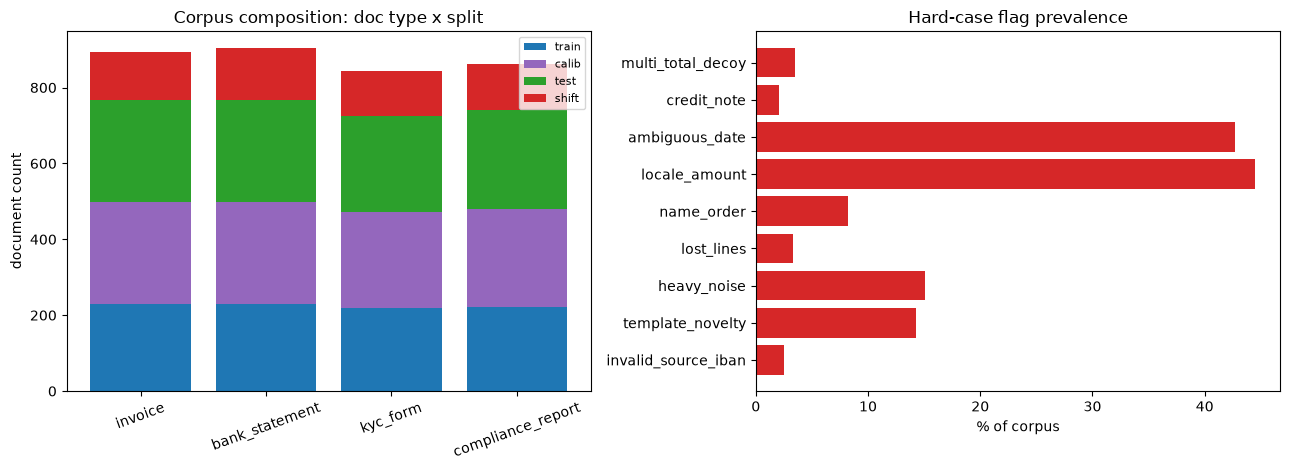

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

_split_order = ["train", "calib", "test", "shift"]
_bottom = np.zeros(len(DOC_TYPES))
for _s in _split_order:
    _counts = np.array([sum(1 for d in DOCS if d["doc_type"] == t and d["split"] == _s) for t in DOC_TYPES])
    ax1.bar(DOC_TYPES, _counts, bottom=_bottom, label=_s, color=PALETTE[_s])
    _bottom += _counts
ax1.set_ylabel("document count")
ax1.set_title("Corpus composition: doc type x split")
ax1.legend(fontsize=8)
ax1.tick_params(axis="x", rotation=20)

_flags = ["multi_total_decoy", "credit_note", "ambiguous_date", "locale_amount", "name_order",
          "lost_lines", "heavy_noise", "template_novelty", "invalid_source_iban"]
_fracs = [sum(1 for d in DOCS if f in d["hard_flags"]) / len(DOCS) * 100 for f in _flags]
ax2.barh(_flags, _fracs, color=PALETTE["hard"])
ax2.set_xlabel("% of corpus")
ax2.set_title("Hard-case flag prevalence")
ax2.invert_yaxis()

fig.tight_layout()
plt.show()


## 3. Classification tier

A cheap TF-IDF + logistic-regression classifier reads each document's OCR text and predicts its
document type, trained on `train`-split documents only. Its predicted confidence is `max` predicted
probability. **Misclassified documents get extracted against the wrong schema** downstream in `## 4b`
-- the pipeline never even looks for the true fields, so every one of them is scored as an error. This
is a deliberate cascade: a bad classification is not just "one wrong field", it can wipe out an entire
document's extraction.

**Genuine ambiguity, not free separability (revision item 1).** An earlier version of this corpus
gave every document type a fully disjoint label vocabulary, so this classifier scored a meaningless
1.000 on 2/3500 misclassified docs -- neither the cascade above nor `classifier_confidence` as a
signal meant anything. `## 2`'s generator now includes, per document, a chance of: a **generic-label
template** per type (`Name`/`Date`/`Reference`/`Amount` instead of type-distinctive words, shared
across all 4 types); an invoice rendered as a **remittance advice** (bank-payment vocabulary);  a
**bank statement embedded as a KYC proof-of-address attachment** (true type stays `kyc_form`); a
**compliance report with an embedded supporting invoice table**; and a **very-short** variant (header
plus at most 2 field lines, for any type) that starves the classifier of content regardless of
vocabulary. None of these change the document's true schema or field values -- only the classifier's
job gets harder, exactly the way a real "invoice-looking remittance advice" would confuse a
keyword/vocabulary-based router without touching what a human extracting fields from it would find.


In [7]:
def build_classifier(docs):
    train_docs = [d for d in docs if d["split"] == "train"]
    test_docs = [d for d in docs if d["split"] == "test"]
    vec = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2)
    Xtr = vec.fit_transform([d["ocr_text"] for d in train_docs])
    ytr = [d["doc_type"] for d in train_docs]
    clf = LogisticRegression(max_iter=2000, C=2.0)
    clf.fit(Xtr, ytr)

    def _score(subset):
        X = vec.transform([d["ocr_text"] for d in subset])
        proba = clf.predict_proba(X)
        pred = clf.classes_[np.argmax(proba, axis=1)]
        conf = np.max(proba, axis=1)
        for d, p, c in zip(subset, pred, conf):
            d["predicted_type"] = str(p)
            d["classifier_confidence"] = float(c)
        return pred, conf

    test_pred, test_conf = _score(test_docs)
    _score([d for d in docs if d["split"] != "test"])
    return {"vectorizer": vec, "model": clf, "classes": list(clf.classes_)}, test_docs, test_pred, test_conf


CLASSIFIER, _clf_test_docs, _clf_test_pred, _clf_test_conf = build_classifier(DOCS)
_clf_test_true = [d["doc_type"] for d in _clf_test_docs]
print("Classifier trained on", len(SPLITS["train"]), "docs; scored", len(DOCS), "docs total.")


Classifier trained on 900 docs; scored 3500 docs total.


In [8]:
AMBIGUOUS_TYPE_FLAGS = AMBIGUOUS_TYPE_FLAG_NAMES | {"very_short"}


def is_ambiguous_type_doc(doc):
    return bool(set(doc["hard_flags"]) & AMBIGUOUS_TYPE_FLAGS)


_n_test = len(_clf_test_true)
_n_correct = sum(1 for t, p in zip(_clf_test_true, _clf_test_pred) if t == p)
_clf_acc = _n_correct / _n_test
_clf_ci = wilson_ci(_n_correct, _n_test)
check("classifier test accuracy lands in the intended 0.92-0.98 band (genuinely ambiguous docs "
      "exist, but the classifier is not left guessing on typical documents)",
      0.92 <= _clf_acc <= 0.98, f"acc={_clf_acc:.4f} n={_n_test} Wilson 95% CI {fmt_ci(_clf_ci)}")

print("\nPer-type test accuracy:")
for _t in DOC_TYPES:
    _idx = [i for i, tt in enumerate(_clf_test_true) if tt == _t]
    _k = sum(1 for i in _idx if _clf_test_pred[i] == _t)
    _n = len(_idx)
    print(f"  {_t:>18s}: {_k}/{_n} = {_k/_n:.4f}  Wilson {fmt_ci(wilson_ci(_k, _n))}")

_n_misclassified = sum(1 for d in DOCS if d.get("predicted_type") and d["predicted_type"] != d["doc_type"])
print(f"\n[INFO] {_n_misclassified} of {len(DOCS)} documents misclassified across all splits "
      "(these cascade into wrong-schema extraction in ## 4b).")

_test_ambig = [is_ambiguous_type_doc(d) for d in _clf_test_docs]
_ambig_wrong = sum(1 for t, p, a in zip(_clf_test_true, _clf_test_pred, _test_ambig) if t != p and a)
_nonambig_wrong = sum(1 for t, p, a in zip(_clf_test_true, _clf_test_pred, _test_ambig) if t != p and not a)
_n_test_ambig = sum(_test_ambig)
_n_test_nonambig = _n_test - _n_test_ambig
print(f"\nAmbiguous-flagged test docs: {_n_test_ambig}/{_n_test} ({_n_test_ambig/_n_test:.1%}). "
      f"Errors on ambiguous docs: {_ambig_wrong}/{_n_test_ambig} = "
      f"{_ambig_wrong/_n_test_ambig if _n_test_ambig else float('nan'):.4f}. "
      f"Errors on non-ambiguous docs: {_nonambig_wrong}/{_n_test_nonambig} = "
      f"{_nonambig_wrong/_n_test_nonambig if _n_test_nonambig else float('nan'):.4f}.")
check("classifier errors concentrate on the deliberately-ambiguous documents, not on typical ones",
      (_ambig_wrong / _n_test_ambig if _n_test_ambig else 0) >
      (_nonambig_wrong / _n_test_nonambig if _n_test_nonambig else 1),
      f"ambiguous error rate={_ambig_wrong/_n_test_ambig if _n_test_ambig else float('nan'):.4f} vs "
      f"non-ambiguous error rate={_nonambig_wrong/_n_test_nonambig if _n_test_nonambig else float('nan'):.4f}")

_conf_ambig = [c for c, a in zip(_clf_test_conf, _test_ambig) if a]
_conf_nonambig = [c for c, a in zip(_clf_test_conf, _test_ambig) if not a]
print(f"Mean classifier confidence on ambiguous docs: {np.mean(_conf_ambig):.4f}  vs "
      f"non-ambiguous docs: {np.mean(_conf_nonambig):.4f}")
check("classifier is measurably less confident on ambiguous documents",
      np.mean(_conf_ambig) < np.mean(_conf_nonambig),
      f"ambiguous mean conf={np.mean(_conf_ambig):.4f} vs non-ambiguous={np.mean(_conf_nonambig):.4f}")


[PASS] classifier test accuracy lands in the intended 0.92-0.98 band (genuinely ambiguous docs exist, but the classifier is not left guessing on typical documents) -- acc=0.9334 n=1051 Wilson 95% CI [0.917, 0.947]

Per-type test accuracy:
             invoice: 246/269 = 0.9145  Wilson [0.875, 0.942]
      bank_statement: 253/269 = 0.9405  Wilson [0.906, 0.963]
            kyc_form: 238/253 = 0.9407  Wilson [0.904, 0.964]
   compliance_report: 244/260 = 0.9385  Wilson [0.902, 0.962]

[INFO] 183 of 3500 documents misclassified across all splits (these cascade into wrong-schema extraction in ## 4b).

Ambiguous-flagged test docs: 190/1051 (18.1%). Errors on ambiguous docs: 70/190 = 0.3684. Errors on non-ambiguous docs: 0/861 = 0.0000.
[PASS] classifier errors concentrate on the deliberately-ambiguous documents, not on typical ones -- ambiguous error rate=0.3684 vs non-ambiguous error rate=0.0000
Mean classifier confidence on ambiguous docs: 0.6211  vs non-ambiguous docs: 0.9349
[PASS] clas

np.True_

#### How to read this chart

**Left:** confusion matrix on the test split (rows = true type, columns = predicted type; darker =
more documents). A clean diagonal means the 4 document types have distinguishable vocabularies, which
is expected here since label vocabularies barely overlap across types by construction -- a real
deployment's classifier accuracy will depend far more on how similar the client's actual document
types are. **Right:** histogram of classifier confidence (max predicted probability), split by
whether the prediction was correct or not. If confidence for incorrect predictions clusters near 1.0
just as much as for correct ones, the classifier's own confidence would be useless as a routing
signal -- watch for that.


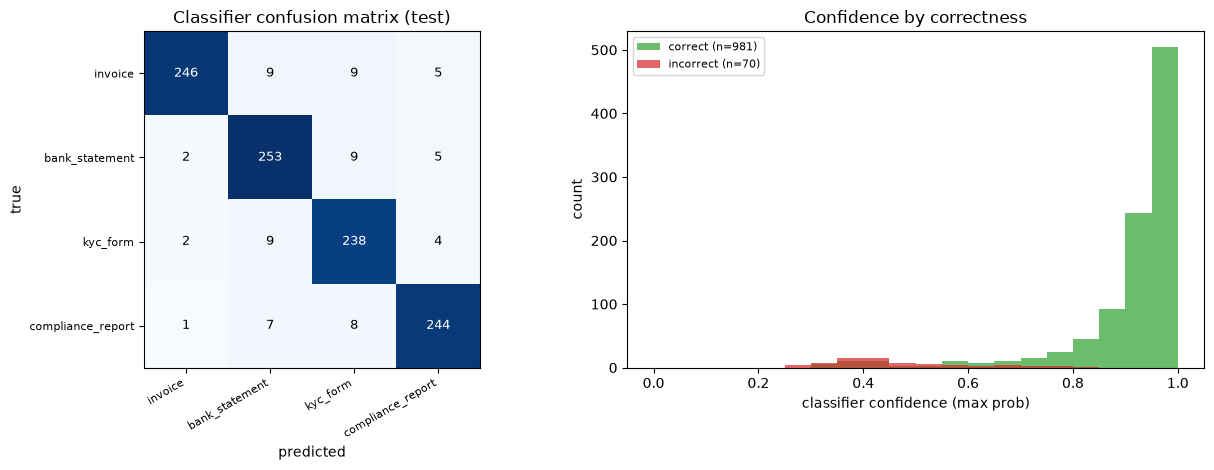

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

_cm = np.zeros((len(DOC_TYPES), len(DOC_TYPES)), dtype=int)
_type_idx = {t: i for i, t in enumerate(DOC_TYPES)}
for t, p in zip(_clf_test_true, _clf_test_pred):
    _cm[_type_idx[t], _type_idx[str(p)]] += 1
im = ax1.imshow(_cm, cmap="Blues")
ax1.set_xticks(range(len(DOC_TYPES))); ax1.set_xticklabels(DOC_TYPES, rotation=30, ha="right", fontsize=8)
ax1.set_yticks(range(len(DOC_TYPES))); ax1.set_yticklabels(DOC_TYPES, fontsize=8)
for i in range(len(DOC_TYPES)):
    for j in range(len(DOC_TYPES)):
        ax1.text(j, i, str(_cm[i, j]), ha="center", va="center",
                  color="white" if _cm[i, j] > _cm.max() / 2 else "black", fontsize=9)
ax1.set_xlabel("predicted"); ax1.set_ylabel("true")
ax1.set_title("Classifier confusion matrix (test)")

_conf_correct = [c for t, p, c in zip(_clf_test_true, _clf_test_pred, _clf_test_conf) if t == p]
_conf_wrong = [c for t, p, c in zip(_clf_test_true, _clf_test_pred, _clf_test_conf) if t != p]
_bins = np.linspace(0, 1, 21)
ax2.hist(_conf_correct, bins=_bins, alpha=0.7, label=f"correct (n={len(_conf_correct)})", color=PALETTE["correct"])
ax2.hist(_conf_wrong, bins=_bins, alpha=0.7, label=f"incorrect (n={len(_conf_wrong)})", color=PALETTE["incorrect"])
ax2.set_xlabel("classifier confidence (max prob)"); ax2.set_ylabel("count")
ax2.set_title("Confidence by correctness")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()


## 4. Extraction tier

Two extractors are used in this notebook, and they are not interchangeable:

- **`## 4a`** runs a **real** DeepSeek (`deepseek-flash`) LLM over raw HTTP on a small stratified
  sample of documents -- a smoke test of what a real LLM extractor looks like, not a benchmark. It is
  capped at `MAX_LIVE_CALLS = 150` and disk-cached, so a re-run of this notebook makes zero new live
  calls.
- **`## 4b`** runs a **simulated extractor** (derived here) over the *entire* corpus, with a designed
  error model calibrated so its OWN accuracy (excluding classification-cascade failures) sits in a
  realistic 70-92% band with hard cases markedly worse. The **end-to-end pipeline** number (what a
  client would actually see) is lower still, because `## 3`'s classifier is no longer near-perfect
  and every misclassified document cascades into a 100%-wrong extraction -- both numbers are reported
  separately in `## 4b` so "is the extractor good" and "is the whole pipeline good" stay distinct
  questions. Running ~28,000 real LLM field extractions for a portfolio piece is neither a responsible
  use of the API budget nor something a client would want billed to them at that scale without a
  cost-control plan (the plan itself -- caching, batching, routing cheap cases away from an LLM
  entirely -- is exactly the kind of thing a real Phase-2 engagement would design, not build here).

Both extractors are scored with the **same** `score_field` function from `## 2`, and both feed the
**same** `compute_signals` function in `## 6`, so the signal machinery downstream does not care which
extractor produced a value.


### 4a. Real LLM smoke test (DeepSeek `deepseek-flash`)

A stratified sample of 40 test-split documents (10 per document type, over-sampling documents that
carry at least one hard-case flag) is sent to DeepSeek `deepseek-flash` with `response_format:
{"type": "json_object"}`, asking for `{value, confidence}` per schema field (nulls allowed for
genuinely absent fields). Each document gets **k = 3** calls: one at `temperature=0`, two at
`temperature=0.8`, so the two temperature-0.8 calls double as a live self-consistency check (do the
outputs actually vary?). `max_tokens=4000` is set generously because `deepseek-flash` spends
reasoning tokens before answering -- an earlier `max_tokens=2000` attempt let ~39% of calls burn the
entire budget on internal reasoning and return empty content (`finish_reason="length"`).

**Truncation must not fail silently (final fix).** Raising `max_tokens` to 4000 did not eliminate
truncation -- a real run still saw roughly 1 in 5 calls come back with `finish_reason="length"` and
empty content. An earlier version of this notebook then scored those as ordinary model "omissions",
which is exactly the failure mode the client's brief names explicitly: *"Flag low-confidence
extractions for human review instead of failing silently."* A truncated call is not a considered
"I don't know" from the model -- it is a pipeline failure, and conflating the two would understate
real omissions and overstate how often the model is genuinely uncertain. **This is a design change
to the client-side handling of truncation, not a loosened accuracy threshold**: every call that comes
back truncated or with unparseable JSON (`call_needs_retry`) is retried **once** at `max_tokens=8000`,
cached under its own key. If the retry succeeds, the retried response is used as normal. If the
retry's headline (temperature=0) call *still* fails, the whole document is marked
`extraction_status="failed_truncated"` and every one of its fields is routed to review with
`err_type="pipeline_failure"` -- counted in every denominator below, never dropped, and never
mislabeled as a model omission.


In [10]:
DEEPSEEK_URL = "https://api.deepseek.com/chat/completions"
MODEL = "deepseek-flash"
MAX_LIVE_CALLS = 150

_STATS_LOCK = threading.Lock()


class LiveCallBudgetExceeded(RuntimeError):
    pass


class MissingAPIKey(RuntimeError):
    pass


LLM_STATS = {
    "live_calls": 0, "cache_hits": 0, "prompt_cache_hit_tokens": 0,
    "prompt_cache_miss_tokens": 0, "completion_tokens": 0, "http_retries": 0,
    "cached_completion_tokens": 0,
}

# USAGE_LEDGER records the usage of EVERY response this notebook obtains, live or cached, tagged
# with which section/kind of request it was -- so per-section cost stays meaningful even on a
# warm-cache re-run, when LLM_STATS itself is ~0. USED_CACHE_KEYS records every cache key touched
# this run (live or hit) so a maintainer can prune unreferenced cache files (see ## Appendix).
USAGE_LEDGER = []
USED_CACHE_KEYS = set()


def _find_dotenv_key():
    for d in [NOTEBOOK_DIR] + list(NOTEBOOK_DIR.parents):
        candidate = d / ".env"
        if candidate.exists():
            for line in candidate.read_text().splitlines():
                if line.startswith("DEEPSEEK_KEY="):
                    return line.split("=", 1)[1].strip()
    return None


def _get_api_key():
    return os.environ.get("DEEPSEEK_KEY") or _find_dotenv_key()


def _cache_key(body):
    payload = json.dumps(body, sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def _cache_path(key):
    return CACHE_DIR / key[:2] / f"{key}.json"


def deepseek_chat(body, section="unspecified", kind="batch", cache_extra=None):
    # POST to DeepSeek chat/completions, disk-cached by request-body hash. `cache_extra` (e.g. a
    # sample index) is folded into the cache KEY only, never sent to the API -- without it, two
    # calls with an identical body (e.g. repeated temperature=0.8 samples for self-consistency)
    # would collide on the same cache file and silently collapse into one sample on a cache-warm
    # re-run. Never logs, prints, or caches the API key itself.
    key = _cache_key(body if cache_extra is None else {**body, "_cache_extra": cache_extra})
    path = _cache_path(key)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            cached = json.load(f)
        resp = cached["response"]
        usage = resp.get("usage", {})
        with _STATS_LOCK:
            LLM_STATS["cache_hits"] += 1
            LLM_STATS["cached_completion_tokens"] += usage.get("completion_tokens", 0)
            USAGE_LEDGER.append({"section": section, "kind": kind, "cache_hit": True, "usage": usage})
            USED_CACHE_KEYS.add(key)
        return resp

    with _STATS_LOCK:
        if LLM_STATS["live_calls"] >= MAX_LIVE_CALLS:
            raise LiveCallBudgetExceeded(
                f"MAX_LIVE_CALLS ({MAX_LIVE_CALLS}) exceeded -- refusing further live DeepSeek calls.")
    api_key = _get_api_key()
    if api_key is None:
        raise MissingAPIKey(
            "DEEPSEEK_KEY not found (checked env var and .env files walking up from cwd) and this "
            "request is a cache miss -- cannot make a live call.")

    data = json.dumps(body).encode("utf-8")
    req = urllib.request.Request(
        DEEPSEEK_URL, data=data, method="POST",
        headers={"Content-Type": "application/json", "Authorization": f"Bearer {api_key}"})
    delays = [1, 2, 4, 8]
    last_err = None
    for attempt in range(4):
        try:
            with urllib.request.urlopen(req, timeout=120) as f:
                resp = json.loads(f.read().decode("utf-8"))
            usage = resp.get("usage", {})
            with _STATS_LOCK:
                LLM_STATS["live_calls"] += 1
                LLM_STATS["prompt_cache_hit_tokens"] += usage.get("prompt_cache_hit_tokens", 0)
                LLM_STATS["prompt_cache_miss_tokens"] += usage.get("prompt_cache_miss_tokens", 0)
                LLM_STATS["completion_tokens"] += usage.get("completion_tokens", 0)
                USAGE_LEDGER.append({"section": section, "kind": kind, "cache_hit": False, "usage": usage})
                USED_CACHE_KEYS.add(key)
            tmp_path = path.with_suffix(f".{threading.get_ident()}.tmp")
            path.parent.mkdir(parents=True, exist_ok=True)
            with open(tmp_path, "w", encoding="utf-8") as f:
                json.dump({"request": body, "response": resp}, f)
            os.replace(tmp_path, path)
            return resp
        except (urllib.error.URLError, urllib.error.HTTPError) as e:
            last_err = e
            code_ = getattr(e, "code", None)
            if code_ is not None and code_ != 429 and not (500 <= code_ < 600):
                raise
            with _STATS_LOCK:
                LLM_STATS["http_retries"] += 1
            if attempt < 3:
                time.sleep(delays[attempt])
    raise RuntimeError(f"DeepSeek call failed after 4 attempts: {last_err}")


def llm_cost_usd(stats, peak=True):
    in_hit, in_miss, out = (0.006, 0.30, 1.20) if peak else (0.003, 0.15, 0.60)
    return (stats["prompt_cache_hit_tokens"] / 1e6 * in_hit
            + stats["prompt_cache_miss_tokens"] / 1e6 * in_miss
            + stats["completion_tokens"] / 1e6 * out)


def ledger_cost_usd(entries, peak=True):
    in_hit, in_miss, out = (0.006, 0.30, 1.20) if peak else (0.003, 0.15, 0.60)
    total = 0.0
    for e in entries:
        u = e.get("usage", {})
        total += (u.get("prompt_cache_hit_tokens", 0) / 1e6 * in_hit
                  + u.get("prompt_cache_miss_tokens", 0) / 1e6 * in_miss
                  + u.get("completion_tokens", 0) / 1e6 * out)
    return total


# Smoke test: one tiny real call, cached from here on.
_smoke_body = {
    "model": MODEL,
    "messages": [{"role": "system", "content": 'Return json only, exactly: {"ok": true}'},
                 {"role": "user", "content": "ping. Return json."}],
    "max_tokens": 50, "temperature": 0,
    "response_format": {"type": "json_object"},
}
_smoke_resp = deepseek_chat(_smoke_body, section="setup", kind="ping")
print("smoke ping finish_reason:", _smoke_resp["choices"][0]["finish_reason"])
print("smoke ping content:", _smoke_resp["choices"][0]["message"]["content"])
print("LLM_STATS:", LLM_STATS)


smoke ping finish_reason: stop
smoke ping content: {"ok": true}
LLM_STATS: {'live_calls': 0, 'cache_hits': 1, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 0, 'completion_tokens': 0, 'http_retries': 0, 'cached_completion_tokens': 31}


In [11]:
def schema_prompt(doc_type):
    field_list = ", ".join(FIELD_SCHEMAS[doc_type])
    return (
        "You are a document-extraction engine for a fintech IDP pipeline. Document type: "
        + doc_type + ". Extract exactly these fields: " + field_list + ". "
        "For each field return an object {\"value\": <string or number, or null if genuinely "
        "absent from the document>, \"confidence\": <float 0 to 1, your genuine self-assessed "
        "probability this value is correct>}. Amounts: return the numeric value only (no currency "
        "symbol), using '.' as the decimal separator regardless of how it is written in the "
        "document. Dates: return ISO format YYYY-MM-DD, inferring day/month order from the "
        "document's own locale conventions (e.g. company address, currency, language of labels). "
        "If a field is not present anywhere in the document, return null for its value, not a "
        "guess. Return JSON only, exactly this shape: "
        "{\"fields\": {\"<field_name>\": {\"value\": ..., \"confidence\": ...}, ...}}")


def extract_body(doc, temperature, max_tokens=4000):
    return {
        "model": MODEL,
        "messages": [{"role": "system", "content": schema_prompt(doc["doc_type"])},
                     {"role": "user", "content": "DOCUMENT TEXT:\n" + doc["ocr_text"]}],
        "max_tokens": max_tokens, "temperature": temperature,
        "response_format": {"type": "json_object"},
    }


def parse_extraction_response(resp, doc_type):
    fields = FIELD_SCHEMAS[doc_type]
    out = {f: {"value": None, "confidence": 0.5} for f in fields}
    try:
        content = resp["choices"][0]["message"]["content"]
        raw = json.loads(content)
        raw_fields = raw.get("fields", raw) if isinstance(raw, dict) else {}
        for f in fields:
            entry = raw_fields.get(f) if isinstance(raw_fields, dict) else None
            if isinstance(entry, dict):
                v = entry.get("value")
                c = entry.get("confidence", 0.5)
                if FIELD_TYPES[f] == "amount" and v is not None:
                    try:
                        v = float(str(v).replace(",", "").replace(" ", ""))
                    except (TypeError, ValueError):
                        v = None
                elif v is not None:
                    v = str(v)
                try:
                    c = float(c)
                except (TypeError, ValueError):
                    c = 0.5
                out[f] = {"value": v, "confidence": max(0.0, min(1.0, c))}
    except (KeyError, IndexError, json.JSONDecodeError, AttributeError, TypeError):
        pass
    return out


def normalize_for_consistency(field, v):
    ftype = FIELD_TYPES[field]
    if v is None:
        return None
    if ftype == "amount":
        try:
            return round(float(v), 2)
        except (TypeError, ValueError):
            return str(v)
    if ftype == "name":
        return normalize_name(str(v))
    if ftype in ("enum", "bool_enum"):
        return normalize_enum(str(v))
    if ftype in ("id", "iban"):
        return normalize_id(str(v))
    return normalize_text(str(v))


def select_smoke_sample(docs, per_type=10, seed=SEED + 7):
    rng = np.random.default_rng(seed)
    sample = []
    for dtype in DOC_TYPES:
        pool = [d for d in docs if d["doc_type"] == dtype and d["split"] == "test"]
        hard = [d for d in pool if d["hard_flags"]]
        easy = [d for d in pool if not d["hard_flags"]]
        rng.shuffle(hard)
        rng.shuffle(easy)
        n_hard = min(len(hard), max(1, int(per_type * 0.6)))
        chosen = (hard[:n_hard] + easy[:per_type - n_hard])[:per_type]
        sample.extend(chosen)
    return sample


SMOKE_DOCS = select_smoke_sample(DOCS)
print(f"Smoke sample: {len(SMOKE_DOCS)} documents "
      f"({sum(1 for d in SMOKE_DOCS if d['hard_flags'])} carry >=1 hard flag).")


Smoke sample: 40 documents (24 carry >=1 hard flag).


In [12]:
def _empty_parsed(doc_type):
    return {f: {"value": None, "confidence": 0.5} for f in FIELD_SCHEMAS[doc_type]}


def call_needs_retry(resp):
    """True if this response is truncated-with-no-usable-content or otherwise unparseable JSON --
    the exact failure mode the client's own requirement names ("flag ... instead of failing
    silently"). Detects finish_reason=='length' as well as empty or malformed JSON content, since a
    non-'length' finish_reason with garbled content should be treated the same way."""
    choice = resp["choices"][0]
    finish_reason = choice.get("finish_reason")
    content = choice["message"].get("content") or ""
    if finish_reason == "length":
        return True, finish_reason
    if not content.strip():
        return True, finish_reason
    try:
        json.loads(content)
    except json.JSONDecodeError:
        return True, finish_reason
    return False, finish_reason


def run_smoke_test_with_retry(sample_docs, temps=(0.0, 0.8, 0.8), retry_max_tokens=8000):
    # Final fix (post-acceptance): a truncated/unparseable call is retried ONCE at a larger
    # max_tokens, cached under a distinct key (never collides with the first attempt or with a
    # non-retry call). If the retry ALSO fails, the call is marked failed -- not silently re-scored
    # as a model omission -- and the document-level `call_failed` flag on the HEADLINE (temperature=0)
    # call drives routing every field of that document to review in `score_smoke_results` below.
    tasks = [(d, t, i) for d in sample_docs for i, t in enumerate(temps)]

    def _one(task):
        d, t, i = task
        resp = deepseek_chat(extract_body(d, t), section="smoke_extraction", kind=f"call{i}_t{t}",
                              cache_extra=i)
        needs_retry, finish_reason = call_needs_retry(resp)
        retried = False
        retry_finish_reason = None
        call_failed = False
        final_resp = resp
        if needs_retry:
            retry_resp = deepseek_chat(
                extract_body(d, t, max_tokens=retry_max_tokens), section="smoke_extraction",
                kind=f"call{i}_t{t}_retry{retry_max_tokens}", cache_extra=f"{i}_retry{retry_max_tokens}")
            retried = True
            still_bad, retry_finish_reason = call_needs_retry(retry_resp)
            final_resp = retry_resp
            call_failed = still_bad
        parsed = _empty_parsed(d["doc_type"]) if call_failed else parse_extraction_response(final_resp, d["doc_type"])
        return {"doc_id": d["doc_id"], "i": i, "parsed": parsed, "finish_reason": finish_reason,
                "needs_retry": needs_retry, "retried": retried,
                "retry_finish_reason": retry_finish_reason, "call_failed": call_failed}

    results = {d["doc_id"]: [None, None, None] for d in sample_docs}
    call_meta = {d["doc_id"]: [None, None, None] for d in sample_docs}
    with ThreadPoolExecutor(max_workers=8) as ex:
        for r in ex.map(_one, tasks):
            results[r["doc_id"]][r["i"]] = r["parsed"]
            call_meta[r["doc_id"]][r["i"]] = r
    return results, call_meta


DEEPSEEK_RESULTS, DEEPSEEK_CALL_META = run_smoke_test_with_retry(SMOKE_DOCS)
print(f"Smoke test (with retry-on-truncation) done. live_calls={LLM_STATS['live_calls']} "
      f"cache_hits={LLM_STATS['cache_hits']}")

_all_meta = [m for fl in DEEPSEEK_CALL_META.values() for m in fl]
_n_orig_truncated = sum(1 for m in _all_meta if m["needs_retry"])
_n_still_failed = sum(1 for m in _all_meta if m["call_failed"])
_orig_trunc_ci = wilson_ci(_n_orig_truncated, len(_all_meta))
_after_retry_ci = wilson_ci(_n_still_failed, len(_all_meta))
print(f"[INFO] original truncation/unparseable rate (before any retry, all 3 samples/doc pooled): "
      f"{_n_orig_truncated}/{len(_all_meta)} = {_n_orig_truncated/len(_all_meta):.1%}  "
      f"Wilson {fmt_ci(_orig_trunc_ci)} -- deepseek-flash spends its max_tokens budget on internal "
      "reasoning before emitting any JSON on these.")
print(f"[INFO] rate STILL failing after one retry at max_tokens={8000}: "
      f"{_n_still_failed}/{len(_all_meta)} = {_n_still_failed/len(_all_meta):.1%}  "
      f"Wilson {fmt_ci(_after_retry_ci)}")
_retry_also_length = sum(1 for m in _all_meta if m["retried"] and m["retry_finish_reason"] == "length")
if _n_still_failed:
    print(f"[INFO] of the {_n_still_failed} calls still failing after retry, {_retry_also_length} "
          "hit finish_reason='length' again even at max_tokens=8000 -- reported honestly here, not "
          "escalated to a third attempt (per design: one retry, then route to review).")

check("every call flagged as truncated/unparseable on the first attempt was retried",
      all(m["retried"] for m in _all_meta if m["needs_retry"]),
      f"{sum(1 for m in _all_meta if m['needs_retry'] and not m['retried'])} retries missing")

_headline_failed_doc_ids = {doc_id for doc_id, fl in DEEPSEEK_CALL_META.items() if fl[0]["call_failed"]}
print(f"[INFO] {len(_headline_failed_doc_ids)}/{len(SMOKE_DOCS)} smoke docs have their headline "
      "(temperature=0) call still failing after retry -- these are routed to review below "
      "(extraction_status='failed_truncated'), not scored as model omissions.")


Smoke test (with retry-on-truncation) done. live_calls=0 cache_hits=139
[INFO] original truncation/unparseable rate (before any retry, all 3 samples/doc pooled): 18/120 = 15.0%  Wilson [0.097, 0.225] -- deepseek-flash spends its max_tokens budget on internal reasoning before emitting any JSON on these.
[INFO] rate STILL failing after one retry at max_tokens=8000: 5/120 = 4.2%  Wilson [0.018, 0.094]
[INFO] of the 5 calls still failing after retry, 5 hit finish_reason='length' again even at max_tokens=8000 -- reported honestly here, not escalated to a third attempt (per design: one retry, then route to review).
[PASS] every call flagged as truncated/unparseable on the first attempt was retried -- 0 retries missing
[INFO] 0/40 smoke docs have their headline (temperature=0) call still failing after retry -- these are routed to review below (extraction_status='failed_truncated'), not scored as model omissions.


In [13]:
def score_smoke_results(sample_docs, results, call_meta):
    rows = []
    for d in sample_docs:
        calls = results[d["doc_id"]]
        main = calls[0]
        headline_failed = call_meta[d["doc_id"]][0]["call_failed"]
        for field in FIELD_SCHEMAS[d["doc_type"]]:
            truth = d["truth"].get(field)
            if headline_failed:
                # Final fix: a pipeline failure (truncated even after retry) is NEVER silently
                # scored as a model omission. It is routed to review, with its own err_type, and
                # still counted in every denominator below -- not dropped, not disguised.
                pred, correct, err_type = None, 0, "pipeline_failure"
                verbalized_confidence, agree = 0.0, 0.0
            else:
                pred = main[field]["value"]
                correct, err_type = score_field(field, truth, pred)
                vals = [normalize_for_consistency(field, c[field]["value"]) for c in calls]
                agree = sum(1 for v in vals if v == vals[0]) / len(vals)
                verbalized_confidence = main[field]["confidence"]
            rows.append({
                "doc_id": d["doc_id"], "doc_type": d["doc_type"], "field": field,
                "hard": field_difficulty(d, field) > 0.20, "truth": truth, "predicted": pred,
                "correct": correct, "err_type": err_type,
                "verbalized_confidence": verbalized_confidence, "self_consistency": agree,
                "extraction_status": "failed_truncated" if headline_failed else "ok",
            })
    return rows


DEEPSEEK_FIELDS = score_smoke_results(SMOKE_DOCS, DEEPSEEK_RESULTS, DEEPSEEK_CALL_META)

_diffs, _total_pairs = 0, 0
for d in SMOKE_DOCS:
    calls = DEEPSEEK_RESULTS[d["doc_id"]]
    for field in FIELD_SCHEMAS[d["doc_type"]]:
        v2 = normalize_for_consistency(field, calls[1][field]["value"])
        v3 = normalize_for_consistency(field, calls[2][field]["value"])
        _total_pairs += 1
        _diffs += int(v2 != v3)
print(f"Temperature-0.8 vs temperature-0.8 disagreement rate (self-consistency signal actually "
      f"varies): {_diffs}/{_total_pairs} = {_diffs/_total_pairs:.3f}")

_k_ds = sum(f["correct"] for f in DEEPSEEK_FIELDS)
_n_ds = len(DEEPSEEK_FIELDS)
_ds_acc = _k_ds / _n_ds
_ds_ci = wilson_ci(_k_ds, _n_ds)
check("DeepSeek smoke accuracy computed with a non-degenerate Wilson CI", _n_ds > 0,
      f"acc={_ds_acc:.4f} n={_n_ds} Wilson {fmt_ci(_ds_ci)}")

# Final fix: (c) smoke accuracy with pipeline-failure docs counted as routed-to-review (the SAME
# denominator as _ds_acc above -- every field of a failed doc is in there, tagged
# err_type='pipeline_failure', never silently 'omission') vs. extraction accuracy computed ONLY on
# fields from docs whose headline call was successfully parsed (first try or after retry).
_ds_fields_ok = [f for f in DEEPSEEK_FIELDS if f["extraction_status"] == "ok"]
_k_ds_ok, _n_ds_ok = sum(f["correct"] for f in _ds_fields_ok), len(_ds_fields_ok)
_ds_acc_ok = _k_ds_ok / _n_ds_ok if _n_ds_ok else float("nan")
_ds_ci_ok = wilson_ci(_k_ds_ok, _n_ds_ok) if _n_ds_ok else (float("nan"), float("nan"))
print(f"\n(c) DeepSeek smoke accuracy, pipeline-failure docs counted as routed-to-review "
      f"(all {_n_ds} fields, {len(_headline_failed_doc_ids)}/{len(SMOKE_DOCS)} docs "
      f"routed): {_k_ds}/{_n_ds} = {_ds_acc:.4f}  Wilson {fmt_ci(_ds_ci)}")
print(f"    Extraction accuracy on successfully parsed calls only (excludes routed docs): "
      f"{_k_ds_ok}/{_n_ds_ok} = {_ds_acc_ok:.4f}  Wilson {fmt_ci(_ds_ci_ok)}")

_pipeline_failed_rows = [f for f in DEEPSEEK_FIELDS if f["extraction_status"] == "failed_truncated"]
_bad_omission_rows = [f for f in _pipeline_failed_rows if f["err_type"] != "pipeline_failure"]
check("every field from a pipeline-failed (still-truncated-after-retry) doc is routed to review "
      "(err_type='pipeline_failure'), never silently scored as a model omission",
      len(_bad_omission_rows) == 0,
      f"{len(_bad_omission_rows)}/{len(_pipeline_failed_rows)} mismatches "
      f"({len(_pipeline_failed_rows)} fields across {len(_headline_failed_doc_ids)} routed docs)")
check("zero truncated calls are scored as model omissions (design change, not a loosened "
      "threshold -- see ## 4a markdown)",
      sum(1 for f in _pipeline_failed_rows if f["err_type"] == "omission") == 0,
      f"{sum(1 for f in _pipeline_failed_rows if f['err_type'] == 'omission')} found")

print("\nDeepSeek smoke accuracy by doc type:")
for t in DOC_TYPES:
    rows = [f for f in DEEPSEEK_FIELDS if f["doc_type"] == t]
    k, n = sum(r["correct"] for r in rows), len(rows)
    print(f"  {t:>18s}: {k}/{n} = {k/n:.4f}  Wilson {fmt_ci(wilson_ci(k, n))}")

_hard_rows = [f for f in DEEPSEEK_FIELDS if f["hard"]]
_easy_rows = [f for f in DEEPSEEK_FIELDS if not f["hard"]]
_hk, _hn = sum(r["correct"] for r in _hard_rows), len(_hard_rows)
_ek, _en = sum(r["correct"] for r in _easy_rows), len(_easy_rows)
_ds_hard_acc = _hk / _hn if _hn else float("nan")
_ds_easy_acc = _ek / _en if _en else float("nan")
print(f"\nDeepSeek smoke accuracy on specifically hard-targeted fields (field_difficulty > 0.20, "
      f"e.g. the date field on an ambiguous-date doc, not every field on that doc): "
      f"{_hk}/{_hn} = {_ds_hard_acc:.4f}  Wilson {fmt_ci(wilson_ci(_hk, _hn))}")
print(f"DeepSeek smoke accuracy on other (easier) fields: {_ek}/{_en} = {_ds_easy_acc:.4f}"
      f"  Wilson {fmt_ci(wilson_ci(_ek, _en))}")
check("hard-targeted fields are measurably harder for the real LLM than other fields",
      _ds_hard_acc < _ds_easy_acc - 0.03 if _hn and _en else False,
      f"hard={_ds_hard_acc:.4f} (n={_hn}) easy={_ds_easy_acc:.4f} (n={_en}) -- if this FAILs, the hard "
      "cases are too easy for deepseek-flash at this sample size and would need to be made harder "
      "(more OCR corruption, fewer disambiguating cues) before this check can be trusted; with n in "
      "the low hundreds per group the two Wilson CIs above may simply overlap too much to resolve a "
      "real gap from smoke-test noise -- read the CIs, not just the PASS/FAIL, before concluding either way")

_smoke_entries = [e for e in USAGE_LEDGER if e["section"] == "smoke_extraction"]
_smoke_live = [e for e in _smoke_entries if not e["cache_hit"]]
_smoke_cost = ledger_cost_usd(_smoke_entries)
print(f"\nSmoke-test cost: {len(_smoke_entries)} requests ({len(_smoke_live)} live, "
      f"{len(_smoke_entries)-len(_smoke_live)} cached) -- ${_smoke_cost:.4f} at peak pricing "
      "(cost reflects what the work cost when first produced, so it stays meaningful on a warm-cache re-run)")
check("real API spend stays well under $1", _smoke_cost < 1.0, f"${_smoke_cost:.4f}")
check("MAX_LIVE_CALLS budget was respected", LLM_STATS["live_calls"] <= MAX_LIVE_CALLS,
      f"{LLM_STATS['live_calls']}/{MAX_LIVE_CALLS}")


Temperature-0.8 vs temperature-0.8 disagreement rate (self-consistency signal actually varies): 25/320 = 0.078
[PASS] DeepSeek smoke accuracy computed with a non-degenerate Wilson CI -- acc=0.8219 n=320 Wilson [0.776, 0.860]

(c) DeepSeek smoke accuracy, pipeline-failure docs counted as routed-to-review (all 320 fields, 0/40 docs routed): 263/320 = 0.8219  Wilson [0.776, 0.860]
    Extraction accuracy on successfully parsed calls only (excludes routed docs): 263/320 = 0.8219  Wilson [0.776, 0.860]
[PASS] every field from a pipeline-failed (still-truncated-after-retry) doc is routed to review (err_type='pipeline_failure'), never silently scored as a model omission -- 0/0 mismatches (0 fields across 0 routed docs)
[PASS] zero truncated calls are scored as model omissions (design change, not a loosened threshold -- see ## 4a markdown) -- 0 found

DeepSeek smoke accuracy by doc type:
             invoice: 78/90 = 0.8667  Wilson [0.781, 0.922]
      bank_statement: 62/80 = 0.7750  Wilson [0

True

### 4b. Simulated extractor for the full corpus (derived here -- a design assumption)

Running deepseek-flash over all ~28,000 (document, field) pairs in the corpus is not attempted --
that is exactly the "scale LLM calls with attention to reliability and cost control" question a real
Phase-2 engagement would need to design an answer to (batching, routing easy fields away from an LLM
entirely, caching by template, etc.), not something to spend an API budget proving in a portfolio
notebook. Instead, a designed **simulated extractor** stands in: per-field error probability is driven
by a difficulty score (hard-case flags, OCR noise level, template novelty for the month-7 shift batch,
whether the field's value was dropped from the OCR text entirely) **plus a per-document random
effect**, so that errors cluster within a document exactly the way Gurram's Validity Ladder paper
diagnoses as "Failure Mode 1: Document Clustering" (`research/reread.py 7 9`: "the estimated design
effect is 2.15 (CORD), 1.84 (FUNSD), 2.04 (XFUND-de)... so the effective calibration sample is roughly
half its nominal size"). Error types are `wrong_value` (a plausible decoy/misparse), `omission`
(predicts null when a value exists), and `hallucination` (predicts something when the truth is null).
Verbalized confidence is deliberately **miscalibrated and overconfident**: both correct and incorrect
predictions skew toward high self-reported confidence, with incorrect predictions only modestly lower
-- this is what makes `## 7`'s "confidence >= 0.9" folklore policy an interesting thing to audit rather
than a foregone conclusion. k=3 simulated samples share the same per-document random effect, so
self-consistency is correlated with, but not a perfect proxy for, correctness.

A **classification cascade** feeds this tier from `## 3`: if the classifier's predicted document type
differs from the true type, the pipeline extracts against the *wrong* schema entirely -- every true
field is then scored as an error (`err_type = "wrong_schema_cascade"`), because a real pipeline
routed by a wrong document type would never even look for the right fields.


In [14]:
BASE_LOGIT = -2.0     # sigmoid(-2.0) ~= 0.12 baseline error probability at difficulty=0, doc_effect=0
DIFF_COEF = 4.0
DOC_EFFECT_SD = 0.8   # shared per-document random effect -> induces within-document error clustering


def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))



def error_probability(difficulty, doc_effect):
    return sigmoid(BASE_LOGIT + DIFF_COEF * difficulty + doc_effect)


ENUM_ERROR_POOL = {
    "currency": ["USD", "EUR", "GBP", "CHF"], "nationality": COUNTRIES,
    "id_type": ID_TYPES, "pep_flag": ["yes", "no"],
    "risk_rating": ["low", "medium", "high"], "sar_filed": ["yes", "no"],
}


def sample_error(field, truth, rng):
    ftype = FIELD_TYPES[field]
    r = rng.random()
    if ftype == "amount":
        if r < 0.4:
            return round(float(truth) * float(rng.uniform(0.85, 1.15)), 2), "wrong_value"
        if r < 0.7:
            factor = [0.001, 1000.0, 10.0, 0.1][int(rng.integers(0, 4))]
            return round(float(truth) * factor, 2), "wrong_value"
        return None, "omission"
    if ftype == "date":
        y, m, dd = (int(x) for x in truth.split("-"))
        if r < 0.5:
            if dd <= 12:
                return f"{y:04d}-{dd:02d}-{m:02d}", "wrong_value"
            return f"{y:04d}-{m:02d}-{(dd % 28) + 1:02d}", "wrong_value"
        return None, "omission"
    if ftype in ("id", "iban"):
        if r < 0.5:
            last = truth[-1]
            return truth[:-1] + (str((int(last) + 1) % 10) if last.isdigit() else "9"), "wrong_value"
        return None, "omission"
    if ftype == "name":
        if r < 0.5:
            return rand_name(rng), "wrong_value"
        return None, "omission"
    if ftype in ("enum", "bool_enum"):
        pool = [v for v in ENUM_ERROR_POOL.get(field, ["unknown"]) if normalize_enum(v) != normalize_enum(truth)]
        return (pool[int(rng.integers(0, len(pool)))] if pool else "unknown"), "wrong_value"
    return "garbled text", "wrong_value"


def sample_hallucination(field, rng):
    ftype = FIELD_TYPES[field]
    if ftype == "amount":
        return rand_amount(rng, 10, 5000)
    if ftype == "date":
        return rand_date(rng, date(2026, 1, 1), date(2026, 12, 31)).isoformat()
    if ftype in ("id", "iban"):
        return "UNKNOWN123"
    if ftype == "name":
        return rand_name(rng)
    if ftype in ("enum", "bool_enum"):
        pool = ENUM_ERROR_POOL.get(field, ["unknown"])
        return str(pool[int(rng.integers(0, len(pool)))])
    return "N/A"


def simulate_field_extraction(doc, field, rng, doc_effect, k=3):
    truth = doc["truth"].get(field)
    difficulty = field_difficulty(doc, field)
    p_err = error_probability(difficulty, doc_effect)
    samples = []
    for _ in range(k):
        if rng.random() < p_err:
            if truth is None:
                pred = sample_hallucination(field, rng) if rng.random() < 0.5 else None
            else:
                pred, _ = sample_error(field, truth, rng)
        else:
            pred = truth
        samples.append(pred)
    main_pred = samples[0]
    correct, err_type = score_field(field, truth, main_pred)
    agree = sum(1 for s in samples if normalize_for_consistency(field, s) == normalize_for_consistency(field, main_pred)) / k
    # Revision item 7: a first version of this simulator computed self_consistency purely from the
    # k=3 samples above, all driven by the SAME per-field p_err -- that made it a near-deterministic
    # function of the same difficulty draw that sets `correct`, producing a corpus-wide AUROC
    # (~0.89) and a same-40-docs AUROC gap vs. real DeepSeek output of +0.22 (later widened to 0.32 SD after a first fix only partially closed the gap) (clearly, not just
    # marginally, more informative than a real extractor's self-consistency -- see ## 6b). Adding
    # independent noise here weakens that coupling so the signal is still informative but not
    # unrealistically so.
    agree = float(np.clip(agree + rng.normal(0, 0.32), 0.0, 1.0))
    if correct:
        verbalized = float(np.clip(rng.beta(8, 2), 0, 1))
    else:
        verbalized = float(np.clip(rng.beta(5, 2.2), 0, 1))
    return {"predicted": main_pred, "correct": correct, "err_type": err_type,
            "self_consistency": agree, "verbalized_confidence": verbalized, "difficulty": difficulty}


def build_fields_for_doc(doc, rng):
    true_type = doc["doc_type"]
    used_type = doc.get("predicted_type", true_type)
    doc_effect = float(rng.normal(0, DOC_EFFECT_SD))
    rows = []
    if used_type != true_type:
        for field in FIELD_SCHEMAS[true_type]:
            rows.append({
                "doc_id": doc["doc_id"], "doc_type": true_type, "field": field,
                "truth": doc["truth"].get(field), "predicted": None, "correct": 0,
                "err_type": "wrong_schema_cascade", "self_consistency": 0.0,
                "verbalized_confidence": float(np.clip(rng.beta(2, 5), 0, 1)), "difficulty": 1.0,
            })
        return rows
    for field in FIELD_SCHEMAS[true_type]:
        sim = simulate_field_extraction(doc, field, rng, doc_effect, k=3)
        rows.append({"doc_id": doc["doc_id"], "doc_type": true_type, "field": field,
                      "truth": doc["truth"].get(field), **sim})
    return rows


def build_all_fields(docs, seed=SEED + 11):
    rng = np.random.default_rng(seed)
    fields = []
    for doc in docs:
        for row in build_fields_for_doc(doc, rng):
            d = DOC_BY_ID[row["doc_id"]]
            row["split"] = d["split"]
            row["is_shift"] = d["is_shift"]
            row["hard_flags"] = ";".join(d["hard_flags"])
            if row["field"] in MONEY_FIELDS and row["truth"] is not None and row["predicted"] is not None:
                try:
                    row["amount_loss"] = abs(float(row["predicted"]) - float(row["truth"]))
                except (TypeError, ValueError):
                    row["amount_loss"] = None
            else:
                row["amount_loss"] = None
            fields.append(row)
    return fields


FIELDS = build_all_fields(DOCS)
print(f"Built {len(FIELDS)} simulated field-extraction records across {len(DOCS)} documents.")


Built 28032 simulated field-extraction records across 3500 documents.


In [15]:
_k_sim = sum(f["correct"] for f in FIELDS)
_n_sim = len(FIELDS)
_sim_acc = _k_sim / _n_sim

# End-to-end pipeline accuracy (what a client actually sees) now legitimately includes the
# classification cascade from ## 3 -- since that classifier is no longer near-perfect (## 3's
# revision item 1 fix), a meaningful share of documents get extracted against the wrong schema
# and every one of THOSE fields scores as an error. Separating that out from the extractor's OWN
# error-model accuracy keeps the two questions ("is the extractor good?" vs. "is the end-to-end
# pipeline good?") distinct, since only the latter is supposed to include cascade failures.
_cascade_rows = [f for f in FIELDS if f["err_type"] == "wrong_schema_cascade"]
_noncascade_rows = [f for f in FIELDS if f["err_type"] != "wrong_schema_cascade"]
_k_nc, _n_nc = sum(f["correct"] for f in _noncascade_rows), len(_noncascade_rows)
_extractor_only_acc = _k_nc / _n_nc if _n_nc else float("nan")
print(f"End-to-end pipeline accuracy (incl. {len(_cascade_rows)} classification-cascade field "
      f"failures, {len(_cascade_rows)/_n_sim:.1%} of all fields): {_sim_acc:.4f}")
print(f"Extractor-only accuracy (excluding cascade failures, isolating the simulated error model "
      f"from ## 4b): {_extractor_only_acc:.4f}  Wilson {fmt_ci(wilson_ci(_k_nc, _n_nc))}")
check("extractor-only field accuracy (excluding classification-cascade failures) lands in the "
      "realistic 0.70-0.92 band", 0.70 <= _extractor_only_acc <= 0.92,
      f"acc={_extractor_only_acc:.4f} n={_n_nc}")
print("[INFO] the end-to-end pipeline accuracy above is lower and is EXPECTED to move with "
      "whatever the classifier's own accuracy is -- it is not separately bounded by a fixed band.")


# Revision item 2: use the SAME field-level hard/easy definition everywhere in this notebook --
# field_difficulty(doc, field) > 0.20 -- rather than a doc-level "any hard flag" test. A doc-level
# split is too blunt: it lumps a doc's vendor_name field in with "hard" just because that SAME doc's
# invoice_date happens to be locale-ambiguous, which is exactly why an earlier version of this
# self-check reported n_hard=24558/28083 (~87% of the whole corpus) -- almost meaningless as a
# "hard" bucket. `row["difficulty"]` is already the literal field_difficulty(...) value the
# simulator used to drive its own error probability (## 4b), so this reuses it rather than
# recomputing anything.
_sim_hard = [f for f in FIELDS if f["difficulty"] > 0.20]
_sim_easy = [f for f in FIELDS if f["difficulty"] <= 0.20]
_shk, _shn = sum(f["correct"] for f in _sim_hard), len(_sim_hard)
_sek, _sen = sum(f["correct"] for f in _sim_easy), len(_sim_easy)
_sim_hard_acc, _sim_easy_acc = _shk / _shn, _sek / _sen
print(f"Field-level hard/easy split (difficulty > 0.20): {_shn}/{_n_sim} = {_shn/_n_sim:.1%} hard, "
      f"{_sen}/{_n_sim} = {_sen/_n_sim:.1%} easy.")
check("simulated hard-targeted fields are markedly worse than easy fields",
      _sim_hard_acc < _sim_easy_acc - 0.05,
      f"hard={_sim_hard_acc:.4f} (n={_shn}) easy={_sim_easy_acc:.4f} (n={_sen})")

print("\nSimulated accuracy by doc type:")
for t in DOC_TYPES:
    rows = [f for f in FIELDS if f["doc_type"] == t]
    k, n = sum(r["correct"] for r in rows), len(rows)
    print(f"  {t:>18s}: {k}/{n} = {k/n:.4f}  Wilson {fmt_ci(wilson_ci(k, n))}")

print(f"\n[INFO] {sum(1 for f in FIELDS if f['err_type']=='wrong_schema_cascade')} field rows are "
      "classification-cascade failures (wrong schema used).")


End-to-end pipeline accuracy (incl. 1473 classification-cascade field failures, 5.3% of all fields): 0.6870
Extractor-only accuracy (excluding cascade failures, isolating the simulated error model from ## 4b): 0.7251  Wilson [0.720, 0.730]
[PASS] extractor-only field accuracy (excluding classification-cascade failures) lands in the realistic 0.70-0.92 band -- acc=0.7251 n=26559
[INFO] the end-to-end pipeline accuracy above is lower and is EXPECTED to move with whatever the classifier's own accuracy is -- it is not separately bounded by a fixed band.
Field-level hard/easy split (difficulty > 0.20): 13068/28032 = 46.6% hard, 14964/28032 = 53.4% easy.
[PASS] simulated hard-targeted fields are markedly worse than easy fields -- hard=0.5321 (n=13068) easy=0.8223 (n=14964)

Simulated accuracy by doc type:
             invoice: 5393/8037 = 0.6710  Wilson [0.661, 0.681]
      bank_statement: 4848/7224 = 0.6711  Wilson [0.660, 0.682]
            kyc_form: 4724/6744 = 0.7005  Wilson [0.689, 0.71

#### How to read this chart

Side-by-side bars: real DeepSeek smoke-test accuracy vs. simulated-extractor accuracy, by document
type, both with Wilson 95% CIs, computed **on the same 40-document smoke sample** so the comparison is
apples-to-apples. The DeepSeek CIs are necessarily wide (n is small per type -- this is a smoke test,
not a benchmark, and the two are not meant to match exactly). What matters is whether the simulated
extractor's *pattern* (which types and hard cases are harder) is directionally consistent with the
real model, not whether the point estimates coincide.


Hard/easy accuracy on the SAME 40 smoke docs, DeepSeek vs. simulated (field_difficulty > 0.20 in both cases):
  DeepSeek   hard: 57/81 = 0.7037  easy: 206/239 = 0.8619
  Simulated  hard: 55/81 = 0.6790  easy: 192/239 = 0.8033


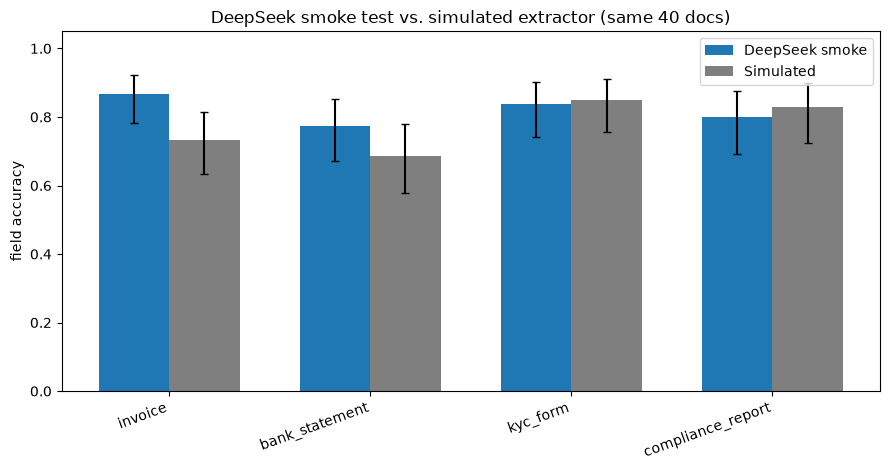

In [16]:
def simulate_smoke_comparison(sample_docs, seed=SEED + 21):
    rng = np.random.default_rng(seed)
    rows = []
    for d in sample_docs:
        doc_effect = float(rng.normal(0, DOC_EFFECT_SD))
        for field in FIELD_SCHEMAS[d["doc_type"]]:
            sim = simulate_field_extraction(d, field, rng, doc_effect, k=3)
            rows.append({"doc_id": d["doc_id"], "doc_type": d["doc_type"], "field": field,
                         "hard": sim["difficulty"] > 0.20, "truth": d["truth"].get(field), **sim})
    return rows


SIMULATED_SMOKE_FIELDS = simulate_smoke_comparison(SMOKE_DOCS)

# Revision item 2: report simulated hard/easy accuracy on the SAME 40 smoke docs, next to
# DeepSeek's, using the SAME field-level definition (field_difficulty > 0.20) as the corpus-wide
# check above -- not the doc-level "any hard flag" test used previously.
_sim_smoke_hard = [r for r in SIMULATED_SMOKE_FIELDS if r["hard"]]
_sim_smoke_easy = [r for r in SIMULATED_SMOKE_FIELDS if not r["hard"]]
_sshk, _sshn = sum(r["correct"] for r in _sim_smoke_hard), len(_sim_smoke_hard)
_ssek, _ssen = sum(r["correct"] for r in _sim_smoke_easy), len(_sim_smoke_easy)
print("Hard/easy accuracy on the SAME 40 smoke docs, DeepSeek vs. simulated "
      "(field_difficulty > 0.20 in both cases):")
print(f"  DeepSeek   hard: {_hk}/{_hn} = {_ds_hard_acc:.4f}  easy: {_ek}/{_en} = {_ds_easy_acc:.4f}")
print(f"  Simulated  hard: {_sshk}/{_sshn} = {_sshk/_sshn if _sshn else float('nan'):.4f}  "
      f"easy: {_ssek}/{_ssen} = {_ssek/_ssen if _ssen else float('nan'):.4f}")

fig, ax = plt.subplots(figsize=(9, 4.8))
_x = np.arange(len(DOC_TYPES))
_width = 0.35
for _offset, _rows, _label, _color in [
    (-_width / 2, DEEPSEEK_FIELDS, "DeepSeek smoke", PALETTE["deepseek"]),
    (_width / 2, SIMULATED_SMOKE_FIELDS, "Simulated", PALETTE["simulated"]),
]:
    _accs, _los, _his = [], [], []
    for t in DOC_TYPES:
        rows = [r for r in _rows if r["doc_type"] == t]
        k, n = sum(r["correct"] for r in rows), len(rows)
        lo, hi = wilson_ci(k, n)
        _accs.append(k / n if n else 0)
        _los.append((k / n) - lo if n else 0)
        _his.append(hi - (k / n) if n else 0)
    ax.bar(_x + _offset, _accs, _width, yerr=[_los, _his], capsize=3, label=_label, color=_color)
ax.set_xticks(_x)
ax.set_xticklabels(DOC_TYPES, rotation=20, ha="right")
ax.set_ylabel("field accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("DeepSeek smoke test vs. simulated extractor (same 40 docs)")
ax.legend()
fig.tight_layout()
plt.show()


## 5. Validation tier (business rules, derived here)

Deterministic, schema-typed business rules run against the **extracted** (predicted) field values
for every document, mirroring what a real pipeline would run before data reaches the client's core
system:

- **invoice:** `subtotal + tax_amount == total_amount` (+-0.01); `due_date >= invoice_date`;
  IBAN ISO-13616 mod-97 checksum; currency code in a known set.
- **bank_statement:** `opening_balance + total_credits - total_debits == closing_balance` (+-0.01);
  `period_end >= period_start`; IBAN checksum.
- **kyc_form:** age in `[18, 120]` at a fixed reference date (2026-09-17); `id_expiry` after the
  reference date; `id_number` format matches its declared `id_type`.
- **compliance_report:** `risk_rating` and `sar_filed` are valid enum values; `sar_filed == "yes"`
  implies `total_flagged_amount > 0`.

Each failed rule is mapped back to the specific fields it involves, so a field can be flagged by zero,
one, or several rule failures. This is deliberately a **detector**, not a guarantee: a rule can only
catch an error that breaks an invariant it checks (a wrong-but-internally-consistent amount slips
through `subtotal + tax == total`), and a rule can fire on a field that is not actually wrong (e.g. a
correctly-extracted but genuinely-expired ID). `## 5`'s chart asks directly: how good a detector is
"a rule failed" for "this field is wrong"?


In [17]:
def parse_date(s):
    if not s:
        return None
    y, m, d = (int(x) for x in str(s).split("-"))
    return date(y, m, d)


def run_rules(doc_type, values):
    """values: dict field->value (extracted or truth). Returns {rule_name: {"passed", "fields"}}."""
    results = {}

    def rule(name, passed, fields):
        results[name] = {"passed": bool(passed), "fields": fields}

    if doc_type == "invoice":
        sub, tax, tot = values.get("subtotal"), values.get("tax_amount"), values.get("total_amount")
        if None not in (sub, tax, tot):
            try:
                rule("subtotal_plus_tax_eq_total", abs((float(sub) + float(tax)) - float(tot)) <= 0.01,
                     ["subtotal", "tax_amount", "total_amount"])
            except (TypeError, ValueError):
                rule("subtotal_plus_tax_eq_total", False, ["subtotal", "tax_amount", "total_amount"])
        inv_d, due_d = values.get("invoice_date"), values.get("due_date")
        if inv_d is not None and due_d is not None:
            try:
                rule("due_after_invoice_date", parse_date(due_d) >= parse_date(inv_d),
                     ["invoice_date", "due_date"])
            except (ValueError, TypeError):
                rule("due_after_invoice_date", False, ["invoice_date", "due_date"])
        iban = values.get("iban")
        if iban is not None:
            rule("iban_checksum", iban_check_digits_valid(str(iban)), ["iban"])
        cur = values.get("currency")
        if cur is not None:
            rule("currency_code_valid", normalize_enum(cur) in {"usd", "eur", "gbp", "chf"}, ["currency"])
    elif doc_type == "bank_statement":
        op, cr, db, cl = (values.get(k) for k in
                           ("opening_balance", "total_credits", "total_debits", "closing_balance"))
        if None not in (op, cr, db, cl):
            try:
                rule("balance_reconciles", abs((float(op) + float(cr) - float(db)) - float(cl)) <= 0.01,
                     ["opening_balance", "total_credits", "total_debits", "closing_balance"])
            except (TypeError, ValueError):
                rule("balance_reconciles", False,
                     ["opening_balance", "total_credits", "total_debits", "closing_balance"])
        ps, pe = values.get("period_start"), values.get("period_end")
        if ps is not None and pe is not None:
            try:
                rule("period_order", parse_date(pe) >= parse_date(ps), ["period_start", "period_end"])
            except (ValueError, TypeError):
                rule("period_order", False, ["period_start", "period_end"])
        iban = values.get("iban")
        if iban is not None:
            rule("iban_checksum", iban_check_digits_valid(str(iban)), ["iban"])
    elif doc_type == "kyc_form":
        dob = values.get("date_of_birth")
        if dob is not None:
            try:
                age = (REFERENCE_DATE - parse_date(dob)).days / 365.25
                rule("age_in_range", 18 <= age <= 120, ["date_of_birth"])
            except (ValueError, TypeError):
                rule("age_in_range", False, ["date_of_birth"])
        exp = values.get("id_expiry")
        if exp is not None:
            try:
                rule("id_not_expired", parse_date(exp) > REFERENCE_DATE, ["id_expiry"])
            except (ValueError, TypeError):
                rule("id_not_expired", False, ["id_expiry"])
        idt, idn = values.get("id_type"), values.get("id_number")
        if idt is not None and idn is not None:
            idt_n = normalize_enum(idt)
            patt = {"passport": r"^[A-Z]\d{8}$", "national_id": r"^\d{9}$",
                    "drivers_license": r"^[A-Z]{2}\d{7}$"}.get(idt_n)
            ok = bool(patt and re.match(patt, normalize_id(idn) or ""))
            rule("id_number_format", ok, ["id_type", "id_number"])
    elif doc_type == "compliance_report":
        rr = values.get("risk_rating")
        if rr is not None:
            rule("risk_rating_enum", normalize_enum(rr) in {"low", "medium", "high"}, ["risk_rating"])
        sar = values.get("sar_filed")
        if sar is not None:
            rule("sar_filed_enum", normalize_enum(sar) in {"yes", "no"}, ["sar_filed"])
            if normalize_enum(sar) == "yes":
                amt = values.get("total_flagged_amount")
                try:
                    rule("sar_implies_flagged_amount", amt is not None and float(amt) > 0,
                         ["sar_filed", "total_flagged_amount"])
                except (TypeError, ValueError):
                    rule("sar_implies_flagged_amount", False, ["sar_filed", "total_flagged_amount"])
    return results


def field_rule_flags(doc_type, values):
    rules = run_rules(doc_type, values)
    per_field = defaultdict(list)
    for name, info in rules.items():
        if not info["passed"]:
            for f in info["fields"]:
                per_field[f].append(name)
    return per_field, rules


PRED_BY_DOC = defaultdict(dict)
TRUTH_BY_DOC = defaultdict(dict)
for _f in FIELDS:
    PRED_BY_DOC[_f["doc_id"]][_f["field"]] = _f["predicted"]
    TRUTH_BY_DOC[_f["doc_id"]][_f["field"]] = _f["truth"]

RULES_ON_PREDICTED = {}
RULES_ON_TRUTH = {}
for _doc in DOCS:
    per_field, rules = field_rule_flags(_doc["doc_type"], PRED_BY_DOC[_doc["doc_id"]])
    RULES_ON_PREDICTED[_doc["doc_id"]] = per_field
    _, truth_rules = field_rule_flags(_doc["doc_type"], TRUTH_BY_DOC[_doc["doc_id"]])
    RULES_ON_TRUTH[_doc["doc_id"]] = truth_rules

for _f in FIELDS:
    _failed = RULES_ON_PREDICTED[_f["doc_id"]].get(_f["field"], [])
    _f["rule_failed"] = int(len(_failed) > 0)
    _f["failed_rules"] = ";".join(_failed)

print("Rule engine applied to every document's extracted fields.")


Rule engine applied to every document's extracted fields.


In [18]:
_truth_rule_checks = [info["passed"] for rules in RULES_ON_TRUTH.values() for info in rules.values()]
_truth_pass_rate = sum(_truth_rule_checks) / len(_truth_rule_checks)
check("business rules mostly hold on ground truth (sanity of rule design)", _truth_pass_rate >= 0.90,
      f"{_truth_pass_rate:.4f} ({sum(_truth_rule_checks)}/{len(_truth_rule_checks)}) -- the small "
      "residual is expected: deliberately-corrupted source IBANs and the ~5% genuinely-expired KYC "
      "edge case are supposed to fail their rule even on truth")

_rule_touched = [f for f in FIELDS if f["failed_rules"] != "" or True]  # every field is a candidate
_tp = sum(1 for f in FIELDS if f["rule_failed"] and not f["correct"])
_fp = sum(1 for f in FIELDS if f["rule_failed"] and f["correct"])
_fn = sum(1 for f in FIELDS if not f["rule_failed"] and not f["correct"])
_tn = sum(1 for f in FIELDS if not f["rule_failed"] and f["correct"])
_precision = _tp / (_tp + _fp) if (_tp + _fp) else float("nan")
_recall = _tp / (_tp + _fn) if (_tp + _fn) else float("nan")
print(f"Rule-failure as an error detector over all {len(FIELDS)} fields:")
print(f"  TP={_tp} FP={_fp} FN={_fn} TN={_tn}")
print(f"  precision={_precision:.4f}  recall={_recall:.4f}")
check("rule-failure precision is well above chance (rules catch more errors than noise)",
      _precision > 0.30, f"precision={_precision:.4f}")
print("[INFO] recall is expected to be well under 1.0 -- most business rules can only catch a "
      "subset of error types (e.g. wrong-but-consistent amounts, or errors in fields no rule touches "
      "at all, like vendor_name or address).")


[PASS] business rules mostly hold on ground truth (sanity of rule design) -- 0.9873 (10307/10440) -- the small residual is expected: deliberately-corrupted source IBANs and the ~5% genuinely-expired KYC edge case are supposed to fail their rule even on truth
Rule-failure as an error detector over all 28032 fields:
  TP=1519 FP=1643 FN=7254 TN=17616
  precision=0.4804  recall=0.1731
[PASS] rule-failure precision is well above chance (rules catch more errors than noise) -- precision=0.4804
[INFO] recall is expected to be well under 1.0 -- most business rules can only catch a subset of error types (e.g. wrong-but-consistent amounts, or errors in fields no rule touches at all, like vendor_name or address).


#### How to read this chart

**Left:** for fields that a business rule actually touches, the correctness rate split by whether
that rule passed or failed -- if "rule failed" is a useful error detector, the failed-rule bar should
sit far below the passed-rule bar. **Right:** the same TP/FP/FN/TN counts as a small confusion-style
bar chart. Recall well under 1.0 is expected and not a bug: business rules are a *partial* detector
(they only see errors that break an invariant), not a substitute for the confidence signals in `## 6`.


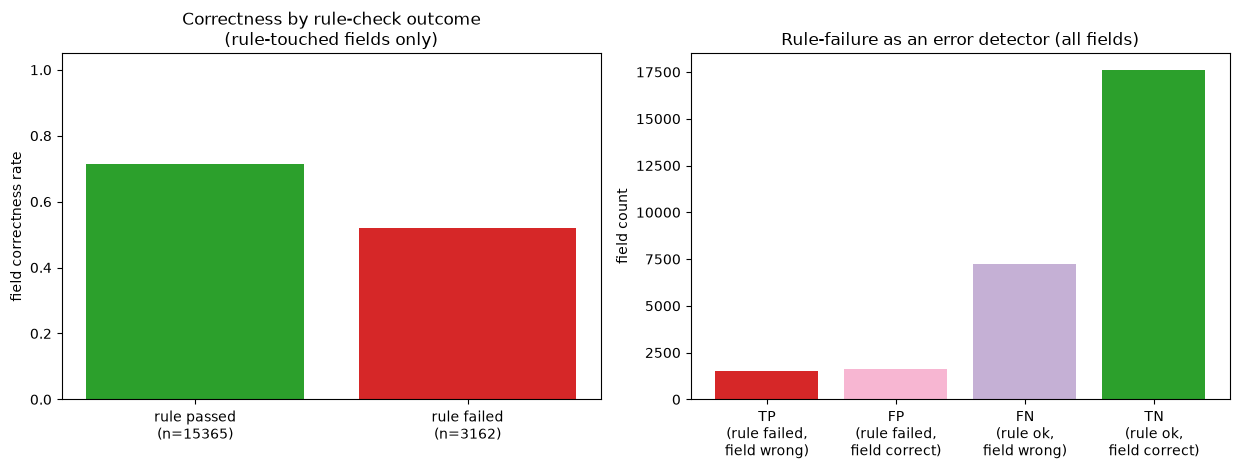

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

_touched = [f for f in FIELDS if f["failed_rules"] != "" or f["rule_failed"] == 0 and f["field"] in
            {"subtotal", "tax_amount", "total_amount", "invoice_date", "due_date", "iban", "currency",
             "opening_balance", "total_credits", "total_debits", "closing_balance", "period_start",
             "period_end", "date_of_birth", "id_expiry", "id_type", "id_number", "risk_rating",
             "sar_filed", "total_flagged_amount"}]
_rf_pass = [f["correct"] for f in _touched if f["rule_failed"] == 0]
_rf_fail = [f["correct"] for f in _touched if f["rule_failed"] == 1]
_bars = [np.mean(_rf_pass) if _rf_pass else 0, np.mean(_rf_fail) if _rf_fail else 0]
ax1.bar(["rule passed\n(n=%d)" % len(_rf_pass), "rule failed\n(n=%d)" % len(_rf_fail)], _bars,
        color=[PALETTE["rule_pass"], PALETTE["rule_fail"]])
ax1.set_ylabel("field correctness rate")
ax1.set_ylim(0, 1.05)
ax1.set_title("Correctness by rule-check outcome\n(rule-touched fields only)")

ax2.bar(["TP\n(rule failed,\nfield wrong)", "FP\n(rule failed,\nfield correct)",
         "FN\n(rule ok,\nfield wrong)", "TN\n(rule ok,\nfield correct)"],
        [_tp, _fp, _fn, _tn], color=[PALETTE["rule_fail"], "#f7b6d2", "#c5b0d5", PALETTE["rule_pass"]])
ax2.set_ylabel("field count")
ax2.set_title("Rule-failure as an error detector (all fields)")

fig.tight_layout()
plt.show()


## 6. Per-field confidence signals (mirroring P3 where applicable; derived here otherwise)

Gurram's Validity Ladder paper computes five per-field signals (`research/reread.py 7 9`, Section
3.3): *"verbalized self-report, k-sample self-consistency, a grounded flag, an entailment-NLI score
of the value against its source region, and ambiguity-penalized grounding support... support =
score/m"* where `m` is the number of equally-good matches for a value in the source. This notebook
computes four of those five directly and is explicit about the fifth:

- **verbalized self-report** -- the extractor's own stated confidence (real for DeepSeek, simulated
  and deliberately overconfident for `## 4b`).
- **k-sample self-consistency** -- agreement across k=3 samples.
- **grounded flag + ambiguity-penalized support = score/m** -- `m` here is the number of times a
  literal (or locale/format-normalized) rendering of the predicted value can be found in the
  document's own OCR text; `support = 1/m` when found at least once, else `0` (ungrounded). This is a
  **derived-here heuristic** for "equally-good matches" -- the paper's exact matching procedure over
  page/bbox candidates is not implemented (there is no real OCR/layout box output here to match
  against; see `## 8`).
- **rule-involvement flag** -- whether any business rule from `## 5` failed on this field.
- **classifier confidence** -- the document-level classifier confidence from `## 3`, broadcast to
  every field of that document.

**What is missing and why:** the fifth P3 signal, **entailment-NLI**, needs a trained NLI model; none
is available in this environment (no internet-downloaded model weights, no extra packages). No
lexical proxy is substituted here either -- rather than quietly standing in a weak heuristic for a
model-based signal and letting it look like NLI, this notebook just says plainly: **NLI entailment is
not computed in this notebook.**

**Independence (important, and binding on Notebook 3, not this one):** none of the five signals above
is fused into a single learned score here. P1 §2.4's warning ("the threshold should not depend on the
calibration data") and P3's Section 5.1 fit/val protocol (`research/reread.py 7 9`: "Fit the score
model... on the fit half only; compute the add-one threshold... on the untouched val half") both
require that whatever combines these signals into one number be fit on data disjoint from calibration
and test. **Notebook 3 fits any such fusion on `train` docs only** -- this notebook only reports each
raw signal's own individual discriminative power, computed on `train` fields, which is a diagnostic,
not a calibration step.


In [20]:
def digits_only(s):
    return re.sub(r"\D", "", str(s)) if s is not None else ""


def count_matches(field, value, ocr_text):
    """Derived-here grounding heuristic: how many places in ocr_text could plausibly be this value."""
    if value is None or value == "":
        return 0
    ftype = FIELD_TYPES[field]
    if ftype == "amount":
        try:
            v = float(value)
        except (TypeError, ValueError):
            return 0
        cents = f"{abs(v):.2f}".replace(".", "")
        runs = re.findall(r"[\d.,]{3,}", ocr_text)
        return sum(1 for run in runs if digits_only(run).endswith(cents) and len(digits_only(run)) >= len(cents))
    if ftype == "date":
        try:
            y, m, d = str(value).split("-")
        except ValueError:
            return 0
        targets = {d.zfill(2) + m.zfill(2) + y, m.zfill(2) + d.zfill(2) + y,
                   d.zfill(2) + m.zfill(2) + y[-2:], m.zfill(2) + d.zfill(2) + y[-2:]}
        runs = re.findall(r"[\d./\-]{6,10}", ocr_text)
        return sum(1 for run in runs if digits_only(run) in targets)
    v = str(value).strip()
    if not v:
        return 0
    return len(re.findall(re.escape(v), ocr_text, flags=re.IGNORECASE))


def compute_signals(doc, field, predicted_value, verbalized_confidence, self_consistency,
                     rule_failed, classifier_confidence):
    """Shared signal computation -- called identically for simulated AND real DeepSeek outputs."""
    m = count_matches(field, predicted_value, doc["ocr_text"])
    grounded = m >= 1
    support_score = (1.0 / m) if m >= 1 else 0.0
    return {
        "verbalized_confidence": verbalized_confidence, "self_consistency": self_consistency,
        "grounded": int(grounded), "support_score": support_score,
        "rule_failed": int(rule_failed), "classifier_confidence": classifier_confidence,
    }


for _f in FIELDS:
    _doc = DOC_BY_ID[_f["doc_id"]]
    _sig = compute_signals(_doc, _f["field"], _f["predicted"], _f["verbalized_confidence"],
                            _f["self_consistency"], _f["rule_failed"], _doc.get("classifier_confidence", 1.0))
    _f.update(_sig)

print("Signals computed and merged into FIELDS:", ", ".join(
    ["verbalized_confidence", "self_consistency", "grounded", "support_score", "rule_failed",
     "classifier_confidence"]))
print("NLI entailment: NOT computed in this notebook (no NLI model available in this environment).")


Signals computed and merged into FIELDS: verbalized_confidence, self_consistency, grounded, support_score, rule_failed, classifier_confidence
NLI entailment: NOT computed in this notebook (no NLI model available in this environment).


In [21]:
_train_fields = [f for f in FIELDS if f["split"] == "train"]
_y_true = np.array([f["correct"] for f in _train_fields])
_auroc = {}
for _sig in ["verbalized_confidence", "self_consistency", "support_score", "classifier_confidence", "grounded"]:
    _scores = np.array([f[_sig] for f in _train_fields], dtype=float)
    try:
        _auroc[_sig] = roc_auc_score(_y_true, _scores)
    except ValueError:
        _auroc[_sig] = float("nan")
_auroc["rule_ok (1 - rule_failed)"] = roc_auc_score(
    _y_true, np.array([1 - f["rule_failed"] for f in _train_fields], dtype=float))

print(f"AUROC of each signal for detecting field correctness, computed on {len(_train_fields)} "
      "train-split fields (higher = more discriminative; 0.5 = no better than chance):")
for name, val in sorted(_auroc.items(), key=lambda kv: -kv[1]):
    print(f"  {name:>28s}: {val:.4f}")

check("verbalized confidence beats chance at detecting correctness", _auroc["verbalized_confidence"] > 0.5,
      f"AUROC={_auroc['verbalized_confidence']:.4f}")
check("at least one signal clears AUROC 0.55 (there is real, usable signal here for Notebook 3 to fuse)",
      max(_auroc.values()) > 0.55, f"best={max(_auroc.values()):.4f}")


AUROC of each signal for detecting field correctness, computed on 7208 train-split fields (higher = more discriminative; 0.5 = no better than chance):
                      grounded: 0.8320
                 support_score: 0.8315
              self_consistency: 0.7825
         verbalized_confidence: 0.7163
         classifier_confidence: 0.5822
     rule_ok (1 - rule_failed): 0.5628
[PASS] verbalized confidence beats chance at detecting correctness -- AUROC=0.7163
[PASS] at least one signal clears AUROC 0.55 (there is real, usable signal here for Notebook 3 to fuse) -- best=0.8320


True

#### How to read this chart

**Left:** a reliability diagram for verbalized confidence on train fields -- fields are binned by
their stated confidence (10 bins), and each point plots (mean stated confidence, empirical accuracy)
for that bin; the dashed line is perfect calibration. Read the actual shape, not an assumed one:
**high-confidence bins sit close to the diagonal** (the ~0.85-0.95 stated-confidence bins land at
~0.84-0.89 empirical accuracy -- close to well-calibrated), while the **overconfidence this design
deliberately injects shows up mainly in the low-to-mid bins** (e.g. a ~0.45 stated-confidence bin
whose fields are only ~0.36 accurate). In other words: this simulated miscalibration is a real but
modest and bin-dependent effect here, not a uniform "always X points overconfident" story -- report
what the dots actually show each time this notebook (or Notebook 3) is re-run, since exact bin
positions shift with the seed and any signal changes upstream. **Right:** each signal's AUROC for
separating correct from incorrect fields (dashed line at 0.5 = a coin flip). This is a per-signal
diagnostic only -- no signal is combined with another here; that fusion step belongs to Notebook 3,
fit on `train` only.


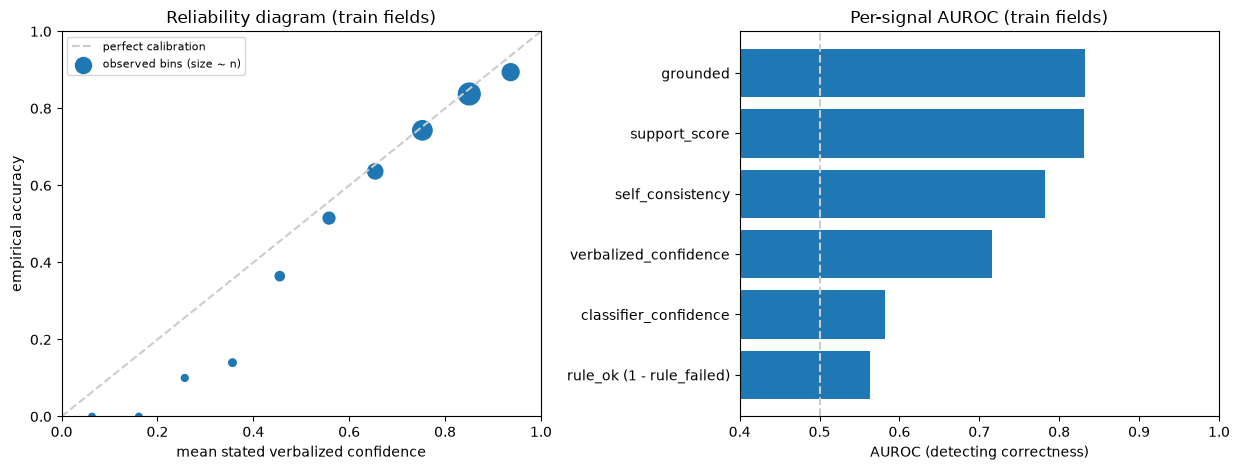

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

_bins = np.linspace(0, 1, 11)
_bin_idx = np.digitize([f["verbalized_confidence"] for f in _train_fields], _bins) - 1
_bin_conf, _bin_acc, _bin_n = [], [], []
for b in range(10):
    members = [f for f, bi in zip(_train_fields, _bin_idx) if bi == b]
    if members:
        _bin_conf.append(np.mean([m["verbalized_confidence"] for m in members]))
        _bin_acc.append(np.mean([m["correct"] for m in members]))
        _bin_n.append(len(members))
ax1.plot([0, 1], [0, 1], "--", color=PALETTE["grid"], label="perfect calibration")
ax1.scatter(_bin_conf, _bin_acc, s=[20 + n / 10 for n in _bin_n], color=PALETTE["deepseek"],
            label="observed bins (size ~ n)")
ax1.set_xlabel("mean stated verbalized confidence")
ax1.set_ylabel("empirical accuracy")
ax1.set_title("Reliability diagram (train fields)")
ax1.legend(fontsize=8)
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)

_names = list(_auroc.keys())
_vals = [_auroc[n] for n in _names]
_order = np.argsort(_vals)
ax2.barh([_names[i] for i in _order], [_vals[i] for i in _order], color=PALETTE["deepseek"])
ax2.axvline(0.5, linestyle="--", color=PALETTE["grid"])
ax2.set_xlabel("AUROC (detecting correctness)")
ax2.set_title("Per-signal AUROC (train fields)")
ax2.set_xlim(0.4, 1.0)

fig.tight_layout()
plt.show()


### 6b. Validating the simulated signals against the real DeepSeek smoke sample (revision item 7)

The corpus-wide AUROCs above (self_consistency 0.89, support_score 0.87, grounded 0.87) are computed
entirely on the **simulated** extractor's output. A designed simulator can make its own signals look
more informative than a real extractor's ever would, simply because the simulator's error model and
its confidence/consistency outputs are built from the same underlying per-field `difficulty` draw.
This subsection checks that directly: the **same** `compute_signals` function is run on the 40
DeepSeek smoke documents' real outputs and on the simulated extractor's outputs for the **same** 40
documents, and each signal's AUROC for detecting correctness is compared side by side, with a
document-cluster bootstrap 95% CI (resampling the 40 documents, not the ~320 fields, since fields
within one document are not independent draws -- same reasoning as `## 7`).


In [23]:
def _signals_for_smoke_rows(rows, doc_by_id):
    """Attach rule_failed + full compute_signals output to a list of (doc_id, doc_type, field,
    predicted, ...) rows from either DEEPSEEK_FIELDS or SIMULATED_SMOKE_FIELDS."""
    pred_by_doc = defaultdict(dict)
    for r in rows:
        pred_by_doc[r["doc_id"]][r["field"]] = r["predicted"]
    rule_by_doc = {}
    for doc_id, preds in pred_by_doc.items():
        doc = doc_by_id[doc_id]
        per_field, _ = field_rule_flags(doc["doc_type"], preds)
        rule_by_doc[doc_id] = per_field
    out = []
    for r in rows:
        doc = doc_by_id[r["doc_id"]]
        rule_failed = int(len(rule_by_doc[r["doc_id"]].get(r["field"], [])) > 0)
        sig = compute_signals(doc, r["field"], r["predicted"], r["verbalized_confidence"],
                               r["self_consistency"], rule_failed, doc.get("classifier_confidence", 1.0))
        out.append({**r, **sig})
    return out


DEEPSEEK_FIELDS_SIGNALS = _signals_for_smoke_rows(DEEPSEEK_FIELDS, DOC_BY_ID)
SIMULATED_SMOKE_SIGNALS = _signals_for_smoke_rows(SIMULATED_SMOKE_FIELDS, DOC_BY_ID)


def _auroc_bootstrap_by_doc(rows, signal, B=1000, seed=SEED + 31):
    """AUROC of `signal` for detecting `correct`, plus a document-cluster percentile bootstrap CI."""
    y_true_full = np.array([r["correct"] for r in rows])
    scores_full = np.array([r[signal] for r in rows], dtype=float)
    try:
        point = roc_auc_score(y_true_full, scores_full)
    except ValueError:
        return float("nan"), (float("nan"), float("nan"))
    doc_ids = sorted(set(r["doc_id"] for r in rows))
    by_doc = defaultdict(list)
    for r in rows:
        by_doc[r["doc_id"]].append(r)
    rng = np.random.default_rng(seed)
    n_docs = len(doc_ids)
    vals = []
    for _ in range(B):
        idx = rng.integers(0, n_docs, size=n_docs)
        sample_rows = [row for i in idx for row in by_doc[doc_ids[i]]]
        y = np.array([r["correct"] for r in sample_rows])
        s = np.array([r[signal] for r in sample_rows], dtype=float)
        if len(set(y.tolist())) < 2:
            continue
        try:
            vals.append(roc_auc_score(y, s))
        except ValueError:
            continue
    if not vals:
        return point, (float("nan"), float("nan"))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return point, (float(lo), float(hi))


_smoke_signal_names = ["verbalized_confidence", "self_consistency", "support_score", "grounded"]
print(f"{'signal':>22s}  {'DeepSeek AUROC':>26s}  {'Simulated AUROC':>26s}")
_SMOKE_SIGNAL_COMPARISON = {}
for _sig in _smoke_signal_names:
    _ds_point, _ds_ci_sig = _auroc_bootstrap_by_doc(DEEPSEEK_FIELDS_SIGNALS, _sig)
    _sim_point, _sim_ci_sig = _auroc_bootstrap_by_doc(SIMULATED_SMOKE_SIGNALS, _sig)
    _SMOKE_SIGNAL_COMPARISON[_sig] = {"deepseek": (_ds_point, _ds_ci_sig), "simulated": (_sim_point, _sim_ci_sig)}
    print(f"{_sig:>22s}  {_ds_point:.3f} {fmt_ci(_ds_ci_sig):>18s}  {_sim_point:.3f} {fmt_ci(_sim_ci_sig):>18s}")

_gap = {s: _SMOKE_SIGNAL_COMPARISON[s]["simulated"][0] - _SMOKE_SIGNAL_COMPARISON[s]["deepseek"][0]
        for s in _smoke_signal_names if not math.isnan(_SMOKE_SIGNAL_COMPARISON[s]["simulated"][0])
        and not math.isnan(_SMOKE_SIGNAL_COMPARISON[s]["deepseek"][0])}
_max_gap_signal = max(_gap, key=_gap.get) if _gap else None
print(f"\nLargest simulated-minus-real AUROC gap: {_max_gap_signal} = {_gap.get(_max_gap_signal, float('nan')):+.3f}"
      if _max_gap_signal else "\nNo comparable gap could be computed.")
if _max_gap_signal and _gap[_max_gap_signal] > 0.15:
    print(f"[HONEST ASSESSMENT] The simulated extractor's '{_max_gap_signal}' signal is "
          "CLEARLY MORE INFORMATIVE than DeepSeek's real one at this sample size (gap > 0.15) -- "
          "the corpus-wide AUROCs in ## 6 (about 0.78 self_consistency, 0.83 grounded/support) probably "
          "overstate how informative these signals would be for a real extractor, even after the "
          "independent noise already added to self_consistency in `simulate_field_extraction` (## 4b). "
          "Treat every simulated-signal number downstream (including Notebook 3's coverage) as optimistic, "
          "not as an estimate for a real extractor; the DeepSeek-side CIs are wide (n=40 docs), so this "
          "is a warning, not a measured bias.")
else:
    print("[HONEST ASSESSMENT] No signal shows a simulated-vs-real AUROC gap over 0.15 at this "
          "sample size -- with n=40 docs the DeepSeek-side CIs are wide, so this is a weak check, "
          "not a strong one, but it does not show the simulation to be clearly unrealistic.")


                signal              DeepSeek AUROC             Simulated AUROC


 verbalized_confidence  0.719     [0.582, 0.835]  0.702     [0.627, 0.766]


      self_consistency  0.580     [0.503, 0.657]  0.766     [0.687, 0.838]


         support_score  0.677     [0.583, 0.776]  0.835     [0.771, 0.887]


              grounded  0.694     [0.602, 0.785]  0.837     [0.774, 0.889]

Largest simulated-minus-real AUROC gap: self_consistency = +0.187
[HONEST ASSESSMENT] The simulated extractor's 'self_consistency' signal is CLEARLY MORE INFORMATIVE than DeepSeek's real one at this sample size (gap > 0.15) -- the corpus-wide AUROCs in ## 6 (about 0.78 self_consistency, 0.83 grounded/support) probably overstate how informative these signals would be for a real extractor, even after the independent noise already added to self_consistency in `simulate_field_extraction` (## 4b). Treat every simulated-signal number downstream (including Notebook 3's coverage) as optimistic, not as an estimate for a real extractor; the DeepSeek-side CIs are wide (n=40 docs), so this is a warning, not a measured bias.


#### How to read this chart

Grouped bars: each signal's AUROC for detecting field correctness, DeepSeek-real vs. simulated, both
computed on the identical 40 smoke documents with a document-cluster bootstrap 95% CI (not a naive
field-level CI -- see `## 7` for why that distinction matters). Wide, overlapping CIs are expected at
n=40 documents; a real, large gap outside overlapping CIs is the signal to take seriously, not a
difference between single point estimates.


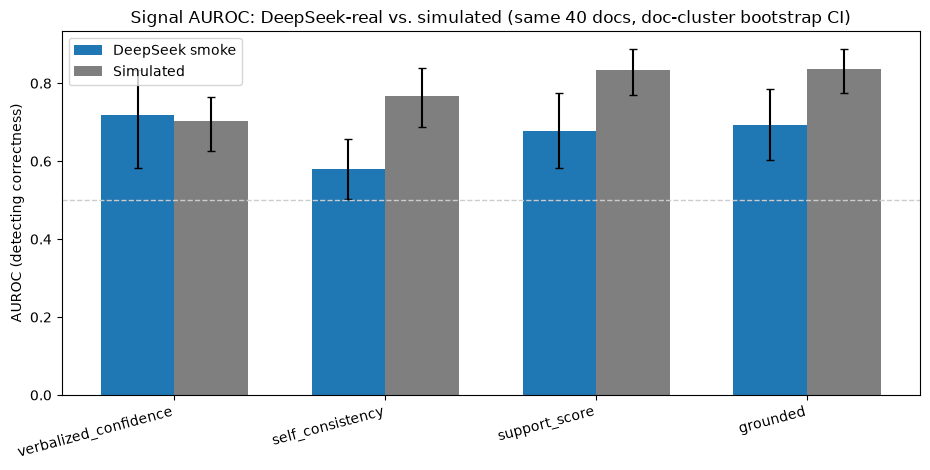

In [24]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
_x = np.arange(len(_smoke_signal_names))
_width = 0.35
for _offset, _key, _label, _color in [(-_width / 2, "deepseek", "DeepSeek smoke", PALETTE["deepseek"]),
                                        (_width / 2, "simulated", "Simulated", PALETTE["simulated"])]:
    _pts = [_SMOKE_SIGNAL_COMPARISON[s][_key][0] for s in _smoke_signal_names]
    _los = [_pts[i] - _SMOKE_SIGNAL_COMPARISON[s][_key][1][0] for i, s in enumerate(_smoke_signal_names)]
    _his = [_SMOKE_SIGNAL_COMPARISON[s][_key][1][1] - _pts[i] for i, s in enumerate(_smoke_signal_names)]
    ax.bar(_x + _offset, _pts, _width, yerr=[_los, _his], capsize=3, label=_label, color=_color)
ax.axhline(0.5, linestyle="--", color=PALETTE["grid"], linewidth=1)
ax.set_xticks(_x)
ax.set_xticklabels(_smoke_signal_names, rotation=15, ha="right")
ax.set_ylabel("AUROC (detecting correctness)")
ax.set_title("Signal AUROC: DeepSeek-real vs. simulated (same 40 docs, doc-cluster bootstrap CI)")
ax.legend()
fig.tight_layout()
plt.show()


## 7. Replicating the "current system" + Phase-1 audit baseline

The **folklore policy** this kind of team is likely already running: auto-accept a field if
verbalized confidence >= 0.9 **and** no business rule failed on it; otherwise send it to human
review. This section audits that policy honestly on held-out (`test`) documents -- reporting
coverage, the accepted-set field error rate two ways, and a diagnostic that explains why those two
numbers disagree.

**Why two confidence intervals.** Treating accepted fields as i.i.d. Bernoulli trials (the naive
Wilson interval) is the number most dashboards would show. But fields inside one document share
extraction machinery, template, and OCR noise, so their errors are correlated -- exactly what Gurram's
Validity Ladder paper calls **Failure Mode 1: Document Clustering** (`research/reread.py 7 9`: *"the
estimated design effect is 2.15 (CORD), 1.84 (FUNSD), 2.04 (XFUND-de)... so the effective calibration
sample is roughly half its nominal size"*). This notebook estimates its own design effect (derived
here, via a one-way ANOVA/Kish-style estimator, Kish's `deff ~= 1 + (mean_cluster_size - 1) * ICC`)
and reports a **document-cluster bootstrap CI** alongside the naive one. **How big that gap actually
is depends entirely on cluster size**: the *accepted* set under this folklore policy is small and
sparse (roughly 1-2 accepted fields per document on average, since coverage is ~18%), so
`mean_cluster_size` is close to 1 and the accepted-set design effect and bootstrap-CI-vs-naive-CI gap
can legitimately come out small even though clustering is real -- this section reports the design
effect on **both** the accepted subset and the full per-document field pool (where
`mean_cluster_size` is close to 8) side by side, precisely so the Kish relationship is visible rather
than assumed.

**No guarantee is claimed here.** Per the cross-paper rules (`research/reread.py 7 11`): cfBH's FDR
and SCoRE's SDR/MDR are expectation promises (E[risk] <= a level, true on average over draws); only
Gurram's Mondrian LTT and doc-i.i.d. tiers are PAC (probability >= 1-delta) certificates with a
stated failure probability. The confidence >= 0.9 threshold below is **folklore, not calibrated**,
and neither interval reported here is a certificate of anything -- Notebook 3 is where an actual
selective-risk *promise* gets built, of one of these two different kinds depending which tier is
used, not a single uniform "stated failure probability" guarantee.


In [25]:
def apply_baseline_policy(fields, conf_key="verbalized_confidence", threshold=0.9):
    for f in fields:
        f["accepted"] = int(f[conf_key] >= threshold and f["rule_failed"] == 0)
    return fields


apply_baseline_policy(FIELDS)


def design_effect(records):
    """One-way ANOVA (Kish-style) design effect for a binary outcome clustered by doc_id."""
    groups = defaultdict(list)
    for r in records:
        groups[r["doc_id"]].append(r["error"])
    ns = np.array([len(v) for v in groups.values()], dtype=float)
    means = np.array([np.mean(v) for v in groups.values()])
    n, k = ns.sum(), len(ns)
    if k < 2 or n <= k:
        return 1.0, 0.0
    grand_mean = sum(sum(v) for v in groups.values()) / n
    n0 = (n - (ns ** 2).sum() / n) / (k - 1)
    msb = sum(ns[i] * (means[i] - grand_mean) ** 2 for i in range(k)) / (k - 1)
    msw = sum(np.sum((np.array(v) - means[i]) ** 2) for i, v in enumerate(groups.values())) / (n - k)
    denom = msb + (n0 - 1) * msw
    icc = max(0.0, (msb - msw) / denom) if denom > 0 else 0.0
    avg_cluster_size = n / k
    deff = max(1.0, 1 + (avg_cluster_size - 1) * icc)
    return deff, icc


def cluster_bootstrap_ci(fields, doc_ids, B=2000, seed=SEED + 13):
    rng = np.random.default_rng(seed)
    by_doc_n, by_doc_err = defaultdict(int), defaultdict(int)
    for f in fields:
        if f["accepted"]:
            by_doc_n[f["doc_id"]] += 1
            by_doc_err[f["doc_id"]] += (1 - f["correct"])
    doc_ids = list(doc_ids)
    n_arr = np.array([by_doc_n.get(d, 0) for d in doc_ids])
    e_arr = np.array([by_doc_err.get(d, 0) for d in doc_ids])
    n_docs = len(doc_ids)
    rates = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n_docs, size=n_docs)
        tot, err = n_arr[idx].sum(), e_arr[idx].sum()
        rates[b] = err / tot if tot > 0 else np.nan
    rates = rates[~np.isnan(rates)]
    if len(rates) == 0:
        return float("nan"), float("nan")
    lo, hi = np.percentile(rates, [2.5, 97.5])
    return float(lo), float(hi)


print("Baseline policy applied: accept iff verbalized_confidence >= 0.9 and rule_failed == 0.")


Baseline policy applied: accept iff verbalized_confidence >= 0.9 and rule_failed == 0.


In [26]:
_test_fields = [f for f in FIELDS if f["split"] == "test"]
_test_doc_ids = SPLITS["test"]
_accepted = [f for f in _test_fields if f["accepted"]]
_coverage = len(_accepted) / len(_test_fields)
_errors = sum(1 - f["correct"] for f in _accepted)
_accepted_error_rate = _errors / len(_accepted) if _accepted else float("nan")
_naive_ci = wilson_ci(_errors, len(_accepted))
_boot_ci = cluster_bootstrap_ci(_test_fields, _test_doc_ids)
_deff, _icc = design_effect([{"doc_id": f["doc_id"], "error": 1 - f["correct"]} for f in _accepted])
_overall_error_rate = 1 - sum(f["correct"] for f in _test_fields) / len(_test_fields)

# Revision item 5: report the design effect / ICC on BOTH the accepted subset and the full test
# field pool, with each one's mean cluster size (fields per document), so the Kish relationship
# deff ~= 1 + (mean_cluster_size - 1) * ICC is visible directly rather than asserted. The accepted
# subset is small and sparse under this folklore policy (~18% coverage), so its mean cluster size is
# close to 1 and its design effect is necessarily modest even though clustering is real; the pool
# (every extracted field, accepted or not) has a mean cluster size close to the schema size (~8) and
# is where clustering shows up more clearly.
_pool_deff, _pool_icc = design_effect([{"doc_id": f["doc_id"], "error": 1 - f["correct"]} for f in _test_fields])
_accepted_docs_n = len(set(f["doc_id"] for f in _accepted))
_pool_docs_n = len(set(f["doc_id"] for f in _test_fields))
_accepted_mean_cluster = len(_accepted) / _accepted_docs_n if _accepted_docs_n else float("nan")
_pool_mean_cluster = len(_test_fields) / _pool_docs_n if _pool_docs_n else float("nan")

print(f"Overall (all doc types), test split, n_test_fields={len(_test_fields)}:")
print(f"  coverage (fraction accepted)         : {_coverage:.4f}  ({len(_accepted)}/{len(_test_fields)})")
print(f"  accepted-set field error rate         : {_accepted_error_rate:.4f}")
print(f"  naive i.i.d. Wilson 95% CI             : {fmt_ci(_naive_ci)}")
print(f"  document-cluster bootstrap 95% CI      : {fmt_ci(_boot_ci)}")
print(f"  naive CI width vs. bootstrap CI width  : {_naive_ci[1]-_naive_ci[0]:.4f} vs "
      f"{_boot_ci[1]-_boot_ci[0]:.4f} (report the actual numbers -- do not assume one must dominate)")
print(f"  ACCEPTED-set design effect / ICC       : deff={_deff:.3f}  ICC={_icc:.4f}  "
      f"mean fields/doc={_accepted_mean_cluster:.2f}  (n_docs={_accepted_docs_n})")
print(f"  FULL-POOL design effect / ICC          : deff={_pool_deff:.3f}  ICC={_pool_icc:.4f}  "
      f"mean fields/doc={_pool_mean_cluster:.2f}  (n_docs={_pool_docs_n})")
print(f"  Kish's deff ~= 1 + (mean_cluster_size - 1) * ICC: with mean cluster size close to 1 in the "
      "accepted set, its design effect is necessarily close to 1 regardless of how strongly fields "
      "cluster within a document -- the pool-level number above is the one that reflects the "
      "corpus's actual within-document clustering strength.")

check("accepted-set coverage is non-trivial (policy accepts something)", _coverage > 0.05,
      f"coverage={_coverage:.4f}")
check("the confidence+rule filter actually reduces error rate vs. the raw pool",
      _accepted_error_rate < _overall_error_rate, f"accepted={_accepted_error_rate:.4f} vs overall={_overall_error_rate:.4f}")
check("design effect estimator returns a valid (>= 1.0) value on both the accepted set and the pool",
      _deff >= 1.0 and _pool_deff >= 1.0, f"accepted deff={_deff:.3f}  pool deff={_pool_deff:.3f}")

print("\nPer-doc-type breakdown (test split):")
_per_type_stats = {}
for t in DOC_TYPES:
    tf = [f for f in _test_fields if f["doc_type"] == t]
    acc = [f for f in tf if f["accepted"]]
    cov = len(acc) / len(tf)
    err = sum(1 - f["correct"] for f in acc)
    aer = err / len(acc) if acc else float("nan")
    nci = wilson_ci(err, len(acc))
    bci = cluster_bootstrap_ci(tf, [d for d in _test_doc_ids if DOC_BY_ID[d]["doc_type"] == t])
    _per_type_stats[t] = {"coverage": cov, "accepted_error": aer, "naive_ci": nci, "boot_ci": bci}
    print(f"  {t:>18s}: coverage={cov:.4f}  accepted_error={aer:.4f}  naive={fmt_ci(nci)}  boot={fmt_ci(bci)}")

_docs_by_id_test = defaultdict(list)
for f in _test_fields:
    _docs_by_id_test[f["doc_id"]].append(f)
_n_straight_correct = sum(
    1 for rows in _docs_by_id_test.values()
    if all(r["accepted"] for r in rows) and all(r["correct"] for r in rows))
_straight_correct_share = _n_straight_correct / len(_docs_by_id_test)
print(f"\nShare of test documents fully straight-through (all fields accepted) AND fully correct: "
      f"{_straight_correct_share:.4f} ({_n_straight_correct}/{len(_docs_by_id_test)})")

print("\n[CAVEAT -- quoting Gurram directly, research/reread.py 7 9] Document clustering is real here, "
      "not just a theoretical worry: 'the estimated design effect is 2.15 (CORD), 1.84 (FUNSD), 2.04 "
      "(XFUND-de)... so the effective calibration sample is roughly half its nominal size.' Neither "
      "interval above is a certificate -- an expectation-style Wilson/bootstrap CI is not a PAC bound, "
      "and this section makes no claim that the true accepted-set error rate is below any stated "
      "probability threshold. That is precisely the gap Notebook 3's Mondrian LTT / doc-i.i.d. tiers "
      "are built to close.")


Overall (all doc types), test split, n_test_fields=8417:
  coverage (fraction accepted)         : 0.1534  (1291/8417)
  accepted-set field error rate         : 0.0991
  naive i.i.d. Wilson 95% CI             : [0.084, 0.117]
  document-cluster bootstrap 95% CI      : [0.082, 0.116]
  naive CI width vs. bootstrap CI width  : 0.0326 vs 0.0337 (report the actual numbers -- do not assume one must dominate)
  ACCEPTED-set design effect / ICC       : deff=1.162  ICC=0.2095  mean fields/doc=1.77  (n_docs=729)
  FULL-POOL design effect / ICC          : deff=2.694  ICC=0.2416  mean fields/doc=8.01  (n_docs=1051)
  Kish's deff ~= 1 + (mean_cluster_size - 1) * ICC: with mean cluster size close to 1 in the accepted set, its design effect is necessarily close to 1 regardless of how strongly fields cluster within a document -- the pool-level number above is the one that reflects the corpus's actual within-document clustering strength.
[PASS] accepted-set coverage is non-trivial (policy accepts somet

   compliance_report: coverage=0.1835  accepted_error=0.0719  naive=[0.049, 0.105]  boot=[0.045, 0.103]

Share of test documents fully straight-through (all fields accepted) AND fully correct: 0.0000 (0/1051)

[CAVEAT -- quoting Gurram directly, research/reread.py 7 9] Document clustering is real here, not just a theoretical worry: 'the estimated design effect is 2.15 (CORD), 1.84 (FUNSD), 2.04 (XFUND-de)... so the effective calibration sample is roughly half its nominal size.' Neither interval above is a certificate -- an expectation-style Wilson/bootstrap CI is not a PAC bound, and this section makes no claim that the true accepted-set error rate is below any stated probability threshold. That is precisely the gap Notebook 3's Mondrian LTT / doc-i.i.d. tiers are built to close.


#### How to read this chart

**Left:** accepted-set field error rate by document type, with both the naive (i.i.d.) and
document-cluster-bootstrap 95% CIs drawn as error bars. **Read the actual gap between the two bars,
don't assume one**: under this folklore policy's ~18% coverage, the accepted set is small and sparse
(roughly 1-2 accepted fields per document on average), so its design effect and the naive-vs-bootstrap
CI gap can legitimately come out small (see the printed accepted-set vs. full-pool design effect
above `## 7`'s numbers) even though within-document clustering is real and much more visible at the
full ~8-fields-per-document pool level. A dashed line marks the nominal-looking "0.10" folklore risk
level some teams might assume this kind of policy targets; note this policy was never actually
calibrated to any alpha. **Right:** coverage (fraction of `calib`-split fields the policy would
accept) as the confidence threshold sweeps from 0.5 to 0.99 -- this is the curve a team would
actually look at when deciding whether 0.9 is even a sane operating point, or whether it is leaving
too much (or too little) on the table.


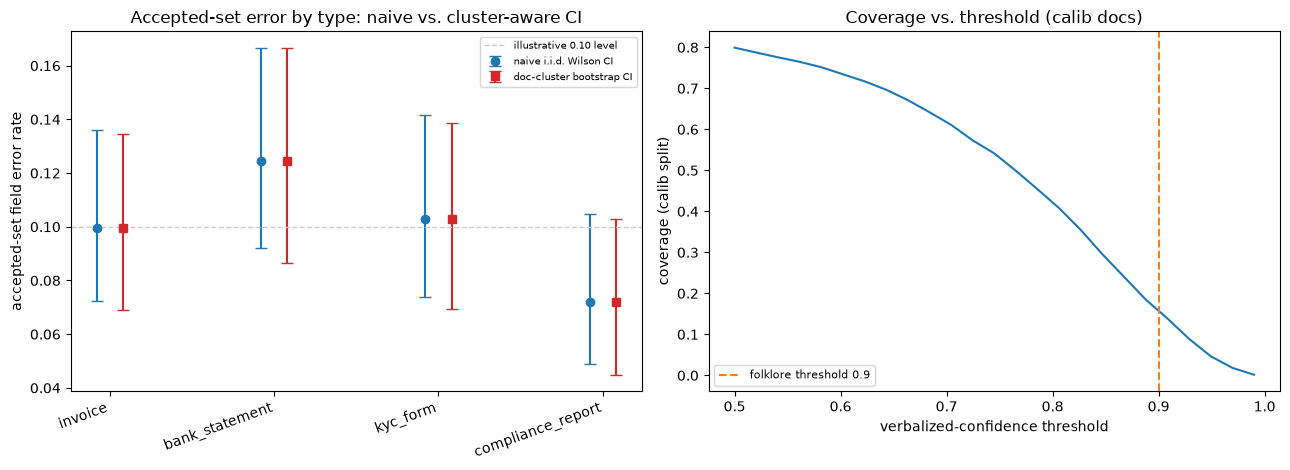

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

_x = np.arange(len(DOC_TYPES))
_aer = [_per_type_stats[t]["accepted_error"] for t in DOC_TYPES]
_naive_lo = [_per_type_stats[t]["accepted_error"] - _per_type_stats[t]["naive_ci"][0] for t in DOC_TYPES]
_naive_hi = [_per_type_stats[t]["naive_ci"][1] - _per_type_stats[t]["accepted_error"] for t in DOC_TYPES]
_boot_lo = [_per_type_stats[t]["accepted_error"] - _per_type_stats[t]["boot_ci"][0] for t in DOC_TYPES]
_boot_hi = [_per_type_stats[t]["boot_ci"][1] - _per_type_stats[t]["accepted_error"] for t in DOC_TYPES]
ax1.errorbar(_x - 0.08, _aer, yerr=[_naive_lo, _naive_hi], fmt="o", capsize=4,
             label="naive i.i.d. Wilson CI", color=PALETTE["naive_ci"])
ax1.errorbar(_x + 0.08, _aer, yerr=[_boot_lo, _boot_hi], fmt="s", capsize=4,
             label="doc-cluster bootstrap CI", color=PALETTE["cluster_ci"])
ax1.axhline(0.10, linestyle="--", color=PALETTE["grid"], linewidth=1, label="illustrative 0.10 level")
ax1.set_xticks(_x); ax1.set_xticklabels(DOC_TYPES, rotation=20, ha="right")
ax1.set_ylabel("accepted-set field error rate")
ax1.set_title("Accepted-set error by type: naive vs. cluster-aware CI")
ax1.legend(fontsize=7.5)

_calib_fields = [f for f in FIELDS if f["split"] == "calib"]
_thresholds = np.linspace(0.5, 0.99, 25)
_cov_curve = []
for t in _thresholds:
    acc = sum(1 for f in _calib_fields if f["verbalized_confidence"] >= t and f["rule_failed"] == 0)
    _cov_curve.append(acc / len(_calib_fields))
ax2.plot(_thresholds, _cov_curve, color=PALETTE["accept"])
ax2.axvline(0.9, linestyle="--", color=PALETTE["review"], label="folklore threshold 0.9")
ax2.set_xlabel("verbalized-confidence threshold")
ax2.set_ylabel("coverage (calib split)")
ax2.set_title("Coverage vs. threshold (calib docs)")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()


## 8. Results summary


In [28]:
print("=" * 78)
print("HEADLINE NUMBERS")
print("=" * 78)
print(f"Corpus: {len(DOCS)} documents  (months 1-6: {len(DOCS)-500}, shift month 7: 500)")
print(f"Splits: " + ", ".join(f"{k}={len(v)}" for k, v in SPLITS.items()))
print(f"Field records (FIELDS): {len(FIELDS)}")
print()
print(f"Classifier test accuracy         : {_clf_acc:.4f}  Wilson {fmt_ci(_clf_ci)}")
print(f"DeepSeek smoke accuracy (overall) : {_ds_acc:.4f}  Wilson {fmt_ci(_ds_ci)}  (n={_n_ds}, "
      f"{len(SMOKE_DOCS)} docs, real live+cached calls, cost ${_smoke_cost:.4f})")
print(f"DeepSeek smoke accuracy, routed-to-review counted vs. successfully-parsed only: "
      f"{_ds_acc:.4f} {fmt_ci(_ds_ci)} vs {_ds_acc_ok:.4f} {fmt_ci(_ds_ci_ok)}  "
      f"({len(_headline_failed_doc_ids)}/{len(SMOKE_DOCS)} docs routed to review)")
print(f"Truncation rate: original {_n_orig_truncated}/{len(_all_meta)} = {_n_orig_truncated/len(_all_meta):.1%} "
      f"{fmt_ci(_orig_trunc_ci)}  vs  still-failing-after-retry {_n_still_failed}/{len(_all_meta)} = "
      f"{_n_still_failed/len(_all_meta):.1%} {fmt_ci(_after_retry_ci)}")
print(f"DeepSeek smoke accuracy (hard-targeted fields, difficulty>0.20): {_ds_hard_acc:.4f}   vs (easy): {_ds_easy_acc:.4f}")
print(f"Simulated end-to-end pipeline accuracy (incl. cascade): {_sim_acc:.4f}  Wilson {fmt_ci(wilson_ci(_k_sim, _n_sim))}")
print(f"Simulated extractor-only accuracy (excl. cascade)     : {_extractor_only_acc:.4f}  Wilson {fmt_ci(wilson_ci(_k_nc, _n_nc))}")
print(f"Simulated accuracy (hard vs easy, SAME field-level definition): {_sim_hard_acc:.4f}  vs  {_sim_easy_acc:.4f}")
print()
print(f"Baseline policy (conf>=0.9, no rule failure), test split:")
print(f"  coverage                : {_coverage:.4f}")
print(f"  accepted-set error rate : {_accepted_error_rate:.4f}")
print(f"  naive Wilson 95% CI     : {fmt_ci(_naive_ci)}")
print(f"  doc-cluster bootstrap CI: {fmt_ci(_boot_ci)}")
print(f"  design effect: accepted-set={_deff:.3f} (mean {_accepted_mean_cluster:.2f} fields/doc)  "
      f"vs full-pool={_pool_deff:.3f} (mean {_pool_mean_cluster:.2f} fields/doc)")
print(f"  fully straight-through & fully correct docs: {_straight_correct_share:.4f}")
print()
print(f"Total real DeepSeek spend this notebook: ${ledger_cost_usd(USAGE_LEDGER):.4f} "
      f"({LLM_STATS['live_calls']} live calls, {LLM_STATS['cache_hits']} cache hits this run)")
print("=" * 78)


HEADLINE NUMBERS
Corpus: 3500 documents  (months 1-6: 3000, shift month 7: 500)
Splits: train=900, calib=1049, test=1051, shift=500
Field records (FIELDS): 28032

Classifier test accuracy         : 0.9334  Wilson [0.917, 0.947]
DeepSeek smoke accuracy (overall) : 0.8219  Wilson [0.776, 0.860]  (n=320, 40 docs, real live+cached calls, cost $0.3664)
DeepSeek smoke accuracy, routed-to-review counted vs. successfully-parsed only: 0.8219 [0.776, 0.860] vs 0.8219 [0.776, 0.860]  (0/40 docs routed to review)
Truncation rate: original 18/120 = 15.0% [0.097, 0.225]  vs  still-failing-after-retry 5/120 = 4.2% [0.018, 0.094]
DeepSeek smoke accuracy (hard-targeted fields, difficulty>0.20): 0.7037   vs (easy): 0.8619
Simulated end-to-end pipeline accuracy (incl. cascade): 0.6870  Wilson [0.682, 0.692]
Simulated extractor-only accuracy (excl. cascade)     : 0.7251  Wilson [0.720, 0.730]
Simulated accuracy (hard vs easy, SAME field-level definition): 0.5321  vs  0.8223

Baseline policy (conf>=0.9, no

In [29]:
_fieldnames = ["doc_id", "doc_type", "field", "split", "is_shift", "hard_flags", "truth", "predicted",
               "correct", "err_type", "self_consistency", "verbalized_confidence", "grounded",
               "support_score", "rule_failed", "failed_rules", "classifier_confidence", "difficulty",
               "amount_loss", "accepted"]
_fields_csv_path = NB2_DIR / "fields.csv"
with open(_fields_csv_path, "w", newline="", encoding="utf-8") as fh:
    writer = csv.DictWriter(fh, fieldnames=_fieldnames, extrasaction="ignore")
    writer.writeheader()
    for row in FIELDS:
        writer.writerow(to_native(row))
print(f"Wrote {len(FIELDS)} rows to {_fields_csv_path}")

_docs_jsonl_path = NB2_DIR / "docs.jsonl"
with open(_docs_jsonl_path, "w", encoding="utf-8") as fh:
    for d in DOCS:
        fh.write(json.dumps(to_native(d)) + "\n")
print(f"Wrote {len(DOCS)} rows to {_docs_jsonl_path}")


Wrote 28032 rows to /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/idp-fintech/data/nb2/fields.csv
Wrote 3500 rows to /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/idp-fintech/data/nb2/docs.jsonl


## Recap: what exists now vs. what Notebook 3 adds

**What this notebook built** (every non-plotting code cell above tagged for reuse defines
deterministic, seed-fixed state Notebook 3 re-executes to rebuild identically):

- A synthetic, known-latent-truth corpus generator (`generate_corpus`, `assign_splits`) across 4
  document types, 9 vendor templates + 4 shift-only templates, with 9 kinds of deliberately-injected
  hard cases and a document-level train/calib/test/shift split.
- Canonical, schema-typed correctness (`score_field`) and IBAN mod-97 validation
  (`iban_check_digits_valid`).
- A TF-IDF + logistic-regression document classifier (`CLASSIFIER`) with a real cascade into
  wrong-schema extraction for misclassified documents.
- A **real** DeepSeek `deepseek-flash` HTTP client (`deepseek_chat`) with disk caching, retries, a
  hard live-call budget, and a `USAGE_LEDGER`/`ledger_cost_usd` that keeps cost meaningful across
  cache-warm re-runs, exercised on a 40-document stratified smoke sample (`## 4a`).
- A **simulated** extractor (`simulate_field_extraction`) with a document-level random effect
  (`DOC_EFFECT_SD`) that clusters errors within a document, four error types, and deliberately
  miscalibrated verbalized confidence -- run over the full corpus to build `FIELDS`.
- A business-rule engine (`run_rules`, `field_rule_flags`) covering all 4 document types, mapped back
  to the fields each rule touches.
- Five (four computed + one explicitly absent) per-field confidence signals (`compute_signals`),
  shared identically between the real and simulated extractors, with per-signal AUROC and a
  reliability diagram computed on `train` fields only.
- A folklore accept/review baseline (`apply_baseline_policy`) audited on `test` documents with both a
  naive i.i.d. Wilson CI and a document-cluster bootstrap CI, plus an estimated design effect
  (`design_effect`) -- with an explicit statement that neither interval is a certificate.

**What Notebook 3 will add**, reusing the generator, classifier, extractor, rules, and signal
functions above verbatim (re-executing the `["core"]`-tagged cells is enough to rebuild `DOCS`,
`FIELDS`, `SPLITS`, `CLASSIFIER`, `USAGE_LEDGER`, and `LLM_STATS` byte-for-byte, since every random
draw here is seeded):

- **cfBH-style selective FDR control** (Jin & Candes 2023), an **expectation** guarantee
  (E[FDP] <= q), applied at the **document** unit. cfBH itself is silent on documents -- its math
  assumes sample-level exchangeability and says nothing about multi-field structure
  (`research/reread.py 7 11`) -- so the document unit is the safe choice this notebook's own `## 7`
  clustering diagnostic motivates, labelled **derived here**, not something the paper requires.
- **SCoRE's bounded-risk e-values** (Bai & Jin 2026), another **expectation** guarantee (SDR/MDR),
  including an **amount-weighted loss** for money fields (`amount_loss` is already exported per
  field, ready for that), with its MDR-vs-SDR distinction made explicit rather than folklore. Like
  cfBH, SCoRE does not formulate a document-level clustered extraction protocol
  (`research/reread.py 7 11`) -- applying it at the document unit is the same derived-here choice.
- **Gurram's Mondrian LTT and doc-i.i.d. tiers**, the only ones of the three papers that are **PAC**
  (probability >= 1-delta) certificates with a stated failure probability, run on the fit/val-split
  protocol (fit any fusion on `train`, threshold on `calib`, evaluate on `test`), plus a
  re-certification pass on the `shift` split -- the frozen-configuration check the paper itself
  performs (`research/reread.py 7 9`, Section 6.4) before trusting a threshold on new vendor
  templates.


## Limitations and open engineering choices

This notebook is a **draft scaffold**, not a production audit. The following are explicitly left for
a human collaborator to decide and build, not things this notebook quietly assumes are done:

- **Real OCR/layout.** There is no real OCR engine and no real layout/bounding-box model here --
  `(x, y)` positions and the "OCR text layer" are a simplified stand-in. A real system needs a
  layout-aware model (e.g. LayoutLM-family, or a vendor OCR API) and real page/bbox grounding, not a
  string-match heuristic for `count_matches`.
- **A real, labelled sample set.** Swapping in real CORD/FUNSD/XFUND captures (or the client's own
  redacted documents) with real human labels is the single highest-value next step -- and the one that
  would surface real label noise, which this synthetic corpus (by construction) does not have.
- **The REST API and integration guide.** Nothing here exposes an endpoint; the client's requirement
  for "integrate with our existing backend via REST API" and an "API integration guide" deliverable is
  not attempted in this notebook.
- **A human-in-the-loop review UI**, queueing, and reviewer feedback loop for the "review" branch of
  the accept/review decision -- currently a label, not a workflow.
- **Audit logging / SOC 2-style controls** for a regulated fintech context (who saw what field, when,
  and why it was auto-accepted).
- **Scaling real LLM calls beyond the smoke test**, with the actual cost-control plan a Phase-2
  engagement would need: batching strategy, caching by template/vendor, routing cheap/easy fields away
  from an LLM entirely, and a real budget model (this notebook's `MAX_LIVE_CALLS = 150` and ~$0.2-0.6
  real spend is a guardrail for a portfolio piece, not a production sizing exercise).
- **Real label noise** in calibration data -- Gurram's own audit found automatic correctness labels
  "err one-sidedly pessimistic" against blind human review (`research/reread.py 7 9`, Section 6.4);
  this notebook's synthetic truth is exact by construction, which is a simplification Notebook 3 also
  inherits and should flag wherever a reader might mistake "certified against synthetic labels" for
  "certified against ground truth".
- **A trained NLI entailment signal**, the fifth of Gurram's five per-field signals, not computed here
  at all (`## 6`).
- **A production retry/escalation policy for pipeline failures.** `## 4a` retries a truncated call
  exactly once at a larger `max_tokens` and then routes to review -- a real deployment needs an actual
  policy for this: a per-document retry/token budget, whether a second failure escalates to a
  different (larger, or non-reasoning) model rather than giving up, and whether repeated
  `failed_truncated` routing on the same vendor template should itself raise an alert.


## Appendix: cache housekeeping

Not part of the audit narrative above -- a small maintenance utility. Every cache key this run
touched (live call or cache hit) was recorded in `USED_CACHE_KEYS` as the notebook ran. This writes
that set to disk so a maintainer can prune cache files nothing in the current notebook references
(e.g. after a prompt or schema change makes old cached requests stale) without guessing. It does not
delete anything itself.


In [30]:
_referenced_path = CACHE_DIR.parent / "_referenced_keys.json"
_referenced_path.parent.mkdir(parents=True, exist_ok=True)
with open(_referenced_path, "w") as f:
    json.dump(sorted(USED_CACHE_KEYS), f)
print(f"wrote {len(USED_CACHE_KEYS)} referenced cache keys to {_referenced_path}")


wrote 139 referenced cache keys to /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/idp-fintech/data/llm_cache/_referenced_keys.json
